# BT4221 Project Group 4 — Spark EDA

## Problem Statement and Class Definition

Traffic congestion and road safety are critical issues for urban planning and emergency response management. This project leverages a countrywide dataset of US traffic accidents, spanning 49 states and collected via real-time traffic APIs from 2016 to 2023. The primary objective is to determine whether the severity of an accident, gauged by its impact on traffic flow, can be accurately predicted using real-time environmental, temporal, and spatial conditions.

The original dataset records accident severity on a scale from 1 to 4 of increasing traffic delay. To improve model performance and focus on identifying factors that lead to significant traffic disruption, the target is reclassified into a binary variable:

*   Low Severity (Class 0): Original levels 1 and 2, representing accidents with minor to moderate impact on traffic flow.
*   High Severity (Class 1): Original levels 3 and 4, representing accidents with significant impact on traffic flow.

The following notebook illustrates the Exploratory Data Analysis, cleaning, and preprocessing steps executed on the dataset.

In [1]:
# Visual helper function (Only for printing purposes)
def border(s):
    print(f"{'='*20} {s} {'='*20}")


## Environment Setup

### Google Colab
Run if you are using Google Colab

In [2]:
# # Install Java
# !apt-get install openjdk-17-jdk-headless -qq > /dev/null

# # Download and install Spark
# !pip install pyspark

# # Install findspark
# !pip install findspark

# # Set environment variables
# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# # Initialise findspark
# import findspark
# !findspark.init()

# # Verify installation
# !java -version
# !pip show pyspark
# !pip show findspark

### Windows
Run if you are using local resources (RUN ONCE)

In [3]:
# # Download and install Spark
# border("Install dependencies")
# !pip3 install pyspark

# # Install findspark
# !pip3 install findspark

# # Initialise findspark
# import findspark
# findspark.init()

# # Set java version
# # import os
# # java_path = "C:\Program Files\Java\jdk-17.0.0.1"
# # os.environ['JAVA_HOME'] = java_path

# # Verify installation
# border("PySpark Version")
# !pip show pyspark
# border("findspark Version")
# !pip show findspark
# border("Hadoop version")
# !hadoop version
# border("Java version")
# !java -version

## Importing Libraries

In [4]:
# Import required libraries
from pyspark.sql import SparkSession

import pyspark.sql.functions as F

from pyspark.sql.types import NumericType, TimestampType, StringType, IntegerType, DoubleType, BooleanType
from pyspark.sql.window import Window

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler
# from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
# from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
# from pyspark.ml.clustering import KMeans, BisectingKMeans
# from pyspark.ml.evaluation import BinaryClassificationEvaluator, RegressionEvaluator, ClusteringEvaluator
# from pyspark.ml.tuning import ParamGridBuilder, CrossValidator



from pyspark.storagelevel import StorageLevel
import string
import time
from pathlib import Path
import psutil
import os

# Visulisations only
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Initialising SparkSession

### Dynamic SparkSession configurations

In [5]:
cores = os.cpu_count()

total_ram_gb = psutil.virtual_memory().total / (1024 ** 3)
driver_memory_gb = int(total_ram_gb * 0.7)
driver_memory = f"{driver_memory_gb}g"

print(f"Cores: {cores}")
print(f"Driver Memory: {driver_memory}")

Cores: 12
Driver Memory: 11g


### Convert CSV file into parquet (RUN ONCE)

In [6]:
# # # Create SparkSession
# if "spark" in locals():
#     spark.stop()
#     print("Existing Spark session stopped.")

# spark = SparkSession.builder \
#     .master("local[*]") \
#     .appName("BT4221_Group4") \
#     .config("spark.driver.memory", driver_memory) \
#     .config("spark.sql.shuffle.partitions", cores * 3) \
#     .config("spark.default.parallelism", cores) \
#     .config("spark.sql.adaptive.enabled", "true") \
#     .getOrCreate()

# # Verify SparkSession created successfully
# print("App:", spark.sparkContext.appName)

# # Read directories
# PROJECT_ROOT = Path.cwd().parent
# ORIGINAL_CSV_PATH = PROJECT_ROOT / "dataset/US_Accidents_March23.csv"

# if not ORIGINAL_CSV_PATH.exists():
#     raise FileNotFoundError(f"Original CSV not found at: {ORIGINAL_CSV_PATH}")

# print("Project root:", PROJECT_ROOT)
# print("Original CSV:", ORIGINAL_CSV_PATH)

# # Read csv
# df = spark.read.csv(str(ORIGINAL_CSV_PATH), header=True, inferSchema=True)

# # Set parquet path
# ORIGINAL_PARQUET_PATH = PROJECT_ROOT / "dataset/US_Accidents_March23_parquet"

# # Write to parquet path
# df.write.mode("overwrite").parquet(str(ORIGINAL_PARQUET_PATH))

# print("Original Parquet:", ORIGINAL_PARQUET_PATH)
# spark.stop()

### Read Parquet Files

In [7]:
# Create SparkSession
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("BT4221_Group4") \
    .config("spark.driver.memory", driver_memory) \
    .config("spark.sql.shuffle.partitions", cores * 3) \
    .config("spark.default.parallelism", cores) \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Verify SparkSession created successfully
print("App:", spark.sparkContext.appName)

# Read directories
PROJECT_ROOT = Path.cwd().parent
ORIGINAL_PARQUET_PATH = PROJECT_ROOT / "dataset/US_Accidents_March23_parquet"

if not ORIGINAL_PARQUET_PATH.exists():
    raise FileNotFoundError(f"Original CSV not found at: {ORIGINAL_PARQUET_PATH}")

print("Project root:", PROJECT_ROOT)
print("Original Parquet:", ORIGINAL_PARQUET_PATH)

# Read parquet files
df = spark.read.parquet(str(ORIGINAL_PARQUET_PATH))

# Print metrics
border("Schema")
df.printSchema()

print()
border("First 5 rows")
df.show(5)

print()
border("Number of rows")
row_count = df.count()
print(row_count)

border("Number of columns")
col_count = df.columns
print(len(col_count))

App: BT4221_Group4
Project root: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project
Original Parquet: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\US_Accidents_March23_parquet
==================== Schema ====================
root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = t

## Check for Missing Values

In [8]:
# Check for missing values across all datasets
def check_missing(df_name, df):
    missing_exprs = []
    for field in df.schema.fields:
        if isinstance(field.dataType, NumericType):
            expr = F.sum((F.col(field.name).isNull() | F.isnan(F.col(field.name))).cast("int")).alias(field.name)
        else:
            expr = F.sum(F.col(field.name).isNull().cast("int")).alias(field.name)
        missing_exprs.append(expr)
    missing_counts = df.select(*missing_exprs)

    border(f"Missing values in {df_name}")
    missing_counts.show()

check_missing("df", df)

==================== Missing values in df ====================
+---+------+--------+----------+--------+---------+---------+-------+-------+------------+-----------+------+----+------+-----+-------+-------+--------+------------+-----------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+----+--------+--------+--------+-------+-------+----------+-------+----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
| ID|Source|Severity|Start_Time|End_Time|Start_Lat|Start_Lng|End_Lat|End_Lng|Distance(mi)|Description|Street|City|County|State|Zipcode|Country|Timezone|Airport_Code|Weather_Timestamp|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Amenity|Bump|Crossing|Give_Way|Junction|No_Exit|Railway|Roundabout|Station|Stop|Traffic_Calming|Traffic_

The initial assessment of the dataset reveals significant variation in data completeness across numerous features.

*   **Geospatial**: `End_Lat` and `End_Lng` columns are missing over 3.4 million entries, which accounts for approximately half the dataset.
*   **Environmental**: Weather-related features show a high frequency of null values, such as `Wind_Chill(F)` with ~2mil missing or `Precipitation(in)` with ~2.2mil missing.
*   **Twilight**: The available twilight markers show a consistent but relatively low number of missing values.

This profile highlights the need for a localised imputation strategy (using `Airport_Code` and  `Month`) to recover as much important environmental context as possible before modeling.

### Drop ID Column

In [9]:
df = df.drop("ID")

The `ID` acts as a unique surrogate key assigned by the data aggregator. To enable duplicate detection, `ID` is dropped so we may later perform a row-wise comparison.
Furthermore, `ID` carries no predictive power and only serves as a label. This does not contribute to our machine learning context.

## Check for Target Variable Imbalance

==================== Checking for imbalance ====================

==================== Table ====================
+--------+-------+----------+
|Severity|  Count|Percentage|
+--------+-------+----------+
|       1|  67366|   0.87167|
|       2|6156981|  79.66702|
|       3|1299337|  16.81251|
|       4| 204710|    2.6488|
+--------+-------+----------+

==================== Barplot ====================


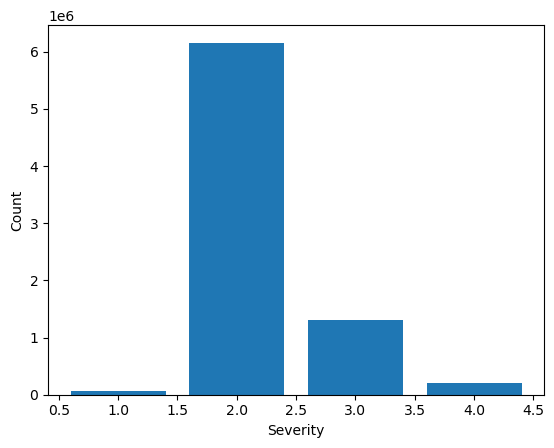

In [10]:
# Checking imbalance in Severity classes
def check_imbalance(df):
    severity_df = df.groupBy("Severity").agg(F.count("*").alias("Count"))

    total_count = severity_df.agg(F.sum("Count")).collect()[0][0]

    severity_df = severity_df.withColumn(
        "Percentage",
        F.round(F.col("Count") / total_count * 100, 5)
        ).orderBy("Severity")

    border("Checking for imbalance")

    # Table
    print()
    border("Table")
    severity_df.show()

    # Barplot
    severity_pd = severity_df.toPandas()
    border("Barplot")
    plt.figure()
    plt.bar(severity_pd["Severity"], severity_pd["Count"])
    plt.xlabel("Severity")
    plt.ylabel("Count")
    plt.show()

check_imbalance(df)

The severity distribution reveals a significant class imbalance. Class 2 accounts for nearly 80 percent of all records, while Class 1 and 4 represent less than 1 percent and 3 percent respectively. This skew suggests that the majority of reported accidents have a moderate impact on traffic.

Since machine learning models often struggle to predict rare classes accurately, this imbalance justifies the grouping of severity levels into a binary classification. Furthermore, this suggests the need for using oversampling or undersampling during preprocessing.

## Check for Duplicates

In [11]:
row_count = df.count()
df = df.dropDuplicates()
dupe_count = row_count - df.count()
print(f"Number of duplicate rows: {dupe_count}")

Number of duplicate rows: 117695


The 117,695 duplicate rows may have arisen from overlapping reports by different traffic APIs. If left in the dataset, the model may overfit on specific recurring incidents. As such, the duplicate records are removed to preserve the statistical integrity of the analysis.

## Dropping Columns

### `Country`, `Turning_Loop` and `Source`

In [12]:
# Checking for Columns to drop
border("Country column")
tbl = df.groupBy("Country").count()
tbl.show()

border("Turning_Loop column")
tbl = df.groupBy("Turning_Loop").count()
tbl.show()

border("Source column")
tbl = df.groupBy("Source").count()
tbl.show()

border("Description column")
tbl = df.select("Description")
tbl.show(10, truncate=False)

==================== Country column ====================
+-------+-------+
|Country|  count|
+-------+-------+
|     US|7610699|
+-------+-------+

==================== Turning_Loop column ====================
+------------+-------+
|Turning_Loop|  count|
+------------+-------+
|       false|7610699|
+------------+-------+

==================== Source column ====================
+-------+-------+
| Source|  count|
+-------+-------+
|Source2|3303245|
|Source1|4210136|
|Source3|  97318|
+-------+-------+

==================== Description column ====================
+----------------------------------------------------------------------------------------------------------------------------------+
|Description                                                                                                                       |
+----------------------------------------------------------------------------------------------------------------------------------+
|Stationary traffic on VA-28 - 

The `Country` column is slated for removal because it contains a single constant string of "US". The feature has zero variance and provides no information to help differentiate between classes.

Similarly, `Turning_Loop` is dropped due to its lack of variability, indicating that no turning loop was ever present in any accident record.

The `Source` column indicates which data provider or API supplied the record. This metadeta does not describe the physical or environmental conditions of the traffic accident, and so is dropped.

### `Wind_Chill(F)`

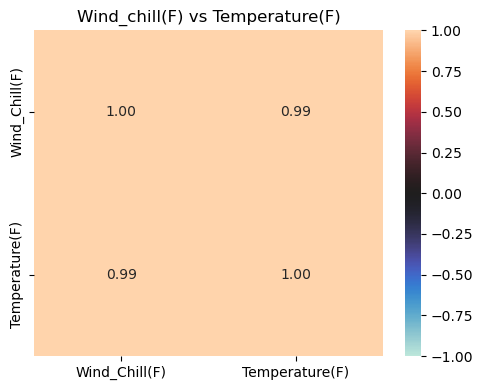

In [13]:
wind_features = ["Wind_Chill(F)", "Temperature(F)"]
assembler = VectorAssembler(inputCols=wind_features, outputCol="features", handleInvalid="skip")
vec_df = assembler.transform(df)

corr_matrix = Correlation.corr(vec_df, "features").head()[0].toArray()
corr_pd = pd.DataFrame(corr_matrix, index=wind_features, columns=wind_features)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_pd, annot=True, fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title("Wind_chill(F) vs Temperature(F)")
plt.tight_layout()
plt.show()

### `End_Lat` and `End_Lng`

#### Removing outliers from `Distance(mi)`

In [14]:
bef_drop_n = df.count()
df = df.filter(
    (F.col("Distance(mi)") < 100)
)
aft_drop_n = df.count()

border("BEFORE")
print(bef_drop_n)

border("AFTER")
print(aft_drop_n)

print("\nRows dropped:", bef_drop_n - aft_drop_n)

==================== BEFORE ====================
7610699
==================== AFTER ====================
7610613

Rows dropped: 86


Filter for Validity: `Distance(mi)` < 100mi
Records with a continuous 100-mile disruption or higher are extremely unlikely to occur from a single traffic accident, and are more likely due to incorrect coordinate logging. As such, these records will be dropped to maintain spatial data quality.

#### Correlation between `Start_Lat`, `Start_Lng`, `End_Lat` and `End_Lng`

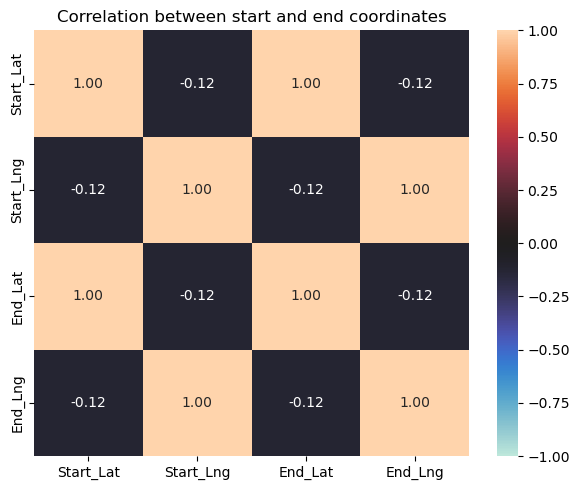

In [15]:
coord_features = ["Start_Lat", "Start_Lng", "End_Lat", "End_Lng"]
assembler = VectorAssembler(inputCols=coord_features, outputCol="features", handleInvalid="skip")
vec_df = assembler.transform(df)

corr_matrix = Correlation.corr(vec_df, "features").head()[0].toArray()
corr_pd = pd.DataFrame(corr_matrix, index=coord_features, columns=coord_features)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_pd, annot=True, fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title("Correlation between start and end coordinates")
plt.tight_layout()
plt.show()

#### Distribution of `Distance(mi)`

==================== Distance distribution graph ====================


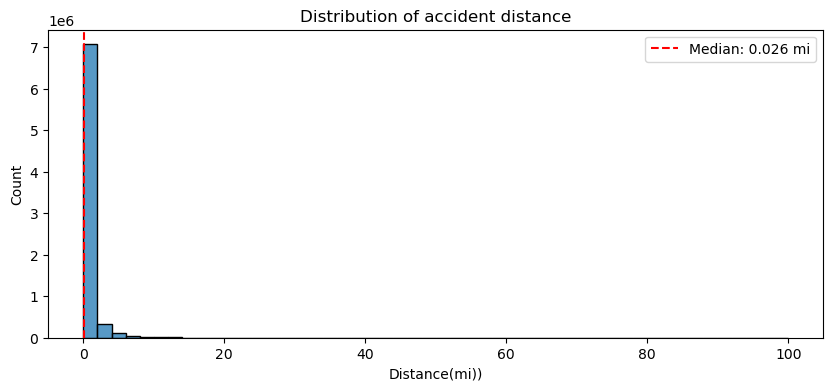

==================== Distance distribution table ====================
+------+------+
|  mean|median|
+------+------+
|0.5558| 0.026|
+------+------+



In [16]:
dist_pd = df.select("Distance(mi)").toPandas()
border("Distance distribution graph")
plt.figure(figsize=(10, 4))
sns.histplot(data=dist_pd, x="Distance(mi)", bins=50)
plt.axvline(dist_pd["Distance(mi)"].median(), color="red", linestyle="--", label=f'Median: {dist_pd["Distance(mi)"].median():.3f} mi')
plt.xlabel("Distance(mi))")
plt.ylabel("Count")
plt.title("Distribution of accident distance")
plt.legend()
plt.show()

border("Distance distribution table")
df.select(
    F.round(F.mean("Distance(mi)"), 4).alias("mean"),
    F.round(F.median("Distance(mi)"), 4).alias("median")
).show()

__explanation to show why end lat and lng arent needed__

In [17]:
cols_to_drop = ["Country", "Turning_Loop", "Source", "End_Lat", "End_Lng", "Description", "Wind_Chill(F)"]
df = df.drop(*cols_to_drop)

border("After dropping")
df.printSchema()

==================== After dropping ====================
root
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Wind_Direction: string (nullable = true)
 |-- Wind_Speed(mph): double (nullable = true)
 |-- Precipitation(in): double (nullable = true)
 |-- Weather_Condition: string (nullab

## Check for Duplicates

In [18]:
row_count = df.count()
df = df.dropDuplicates()
dupe_count = row_count - df.count()
print(f"Number of duplicate rows: {dupe_count}")

Number of duplicate rows: 23203


## Processing Time-based Features

### Processing Start_Time & End_Time Columns

In [19]:
# Standardise Timestamp
df = (
    df.withColumn("Start_Time", F.to_timestamp(F.col("Start_Time"), "yyyy-MM-dd HH:mm:ss"))
      .withColumn("End_Time", F.to_timestamp(F.col("End_Time"), "yyyy-MM-dd HH:mm:ss"))
      .withColumn("Weather_Timestamp", F.to_timestamp(F.col("Weather_Timestamp"), "yyyy-MM-dd HH:mm:ss"))
)

# Extract: year, month, day_of_week, hour, is_weekend
df = df.withColumns({
    "Start_Time_Year": F.year(F.col("Start_Time")),
    "Start_Time_Month": F.month(F.col("Start_Time")),
    "Start_Time_Day_of_Week": F.dayofweek(F.col("Start_Time")),
    "Start_Time_Hour": F.hour(F.col("Start_Time")),
    "Start_Time_is_Weekend": F.when(F.col("Start_Time_Day_of_Week").isin([1, 7]), 1).otherwise(0),
    "End_Time_Year": F.year(F.col("End_Time")),
    "End_Time_Month": F.month(F.col("End_Time")),
    "End_Time_Day_of_Week": F.dayofweek(F.col("End_Time")),
    "End_Time_Hour": F.hour(F.col("End_Time")),
    "End_Time_is_Weekend": F.when(F.col("End_Time_Day_of_Week").isin([1, 7]), 1).otherwise(0)
})

### Dropping Weather_Timestamps

In [20]:
mean_diff = df.select(
    F.mean((F.col("Weather_Timestamp").cast("long") - F.col("Start_Time").cast("long"))).alias("mean_diff_seconds")
).collect()[0]["mean_diff_seconds"]

print(f"Mean difference between 'Start_Time' and 'Weather_Timestamp': {mean_diff} seconds")

Mean difference between 'Start_Time' and 'Weather_Timestamp': 29.616513133941574 seconds


Since the mean difference between `Start_Time` and `Weather_Timestamp` is barely noticeable, we chose to drop `Weather_Timestamp` and keep `Start_Time` to create time-based features

In [21]:
df = df.drop("Weather_Timestamp")

border("After dropping")
df.printSchema()

==================== After dropping ====================
root
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Wind_Direction: string (nullable = true)
 |-- Wind_Speed(mph): double (nullable = true)
 |-- Precipitation(in): double (nullable = true)
 |-- Weather_Condition: string (nullable = true)
 |-- Amenity: boolean (nullable = true)
 

### Drop Data Before 2019

==================== Severity Classes across Start_Time_Year ====================


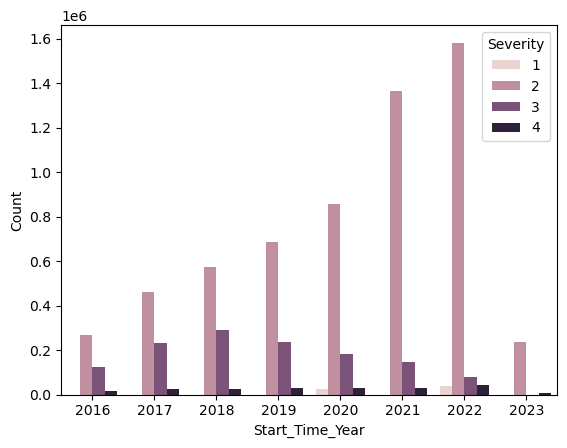

In [22]:
# Barplot of Severity Classes across Start_Time_Year
border("Severity Classes across Start_Time_Year")
temp_df = df.groupBy("Start_Time_Year", "Severity").count().toPandas()

plt.figure()
sns.barplot(data=temp_df, x="Start_Time_Year", y="count", hue="Severity")
plt.xlabel("Start_Time_Year")
plt.ylabel("Count")
plt.show()

From the barchart, a disproportionate increase in Severity 4 incidents from 2018 to 2019 does not correspond with the trends seen in other categories. Such a spike strongly suggests a shift in data collection or severity classification criteria instead of an actual change of real world traffic patterns. As such,  data prior to 2019 will be excluded to ensure the dataset is not skewed by the anomaly.

In [23]:
# Drop data before 2019
df = df.filter(F.col("Start_Time_Year") >= 2019)

### Create & Process Duration Column

In [24]:
df = df.withColumns({
    "Duration_Seconds": F.unix_timestamp(F.col("End_Time")) - F.unix_timestamp(F.col("Start_Time")),
    "Duration_Minutes": (F.unix_timestamp(F.col("End_Time")) - F.unix_timestamp(F.col("Start_Time"))) / 60,
    "Duration_Hours": (F.unix_timestamp(F.col("End_Time")) - F.unix_timestamp(F.col("Start_Time"))) / 3600
})

df.show(5)

+--------+-------------------+-------------------+---------+-------------------+------------+--------------------+---------------+--------------+-----+----------+----------+------------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+--------------+--------------+-----------------+---------------------+---------------+----------------+----------------------+---------------+---------------------+-------------+--------------+--------------------+-------------+-------------------+----------------+------------------+------------------+
|Severity|         Start_Time|           End_Time|Start_Lat|          Start_Lng|Distance(mi)|              Street|           City|        County|State|   Zipcode|  Timezone|Airport_Code|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Pre

### Filtering Duration Based on a Set Threshold

In [25]:
bef_drop_n = df.count()
df = df.filter(
    (F.col("Duration_Minutes") > 5.0) &
    (F.col("Duration_Hours") <= 288.0)
)
aft_drop_n = df.count()

border("BEFORE")
print(bef_drop_n)

border("AFTER")
print(aft_drop_n)

print("\nRows dropped:", bef_drop_n - aft_drop_n)

==================== BEFORE ====================
5572811
==================== AFTER ====================
5568047

Rows dropped: 4764


Filter for Validity: 5 mins < `Duration` <= 288 hours (12 days)  
Accidents lasting less than five minutes may be noise, such as extremely minor stalls or transient traffic sensor glitches. Accidents lasting more than 288 hours are statistically improbable to occur. Instead, these entires may represent long-term roadwork or seasonal closures instead of individual traffic incidents. As such, this filter is applied on `Duration` to refine the focus of the dataset on actual traffic incidents and reduce noise.

### Plotting Accident Counts by Time-based Features (Grouped by Severity)

In [26]:
unique_severity = [row["Severity"] for row in df.select("Severity").distinct().collect()]

==================== Accident % by Year (Severity = 1) ====================


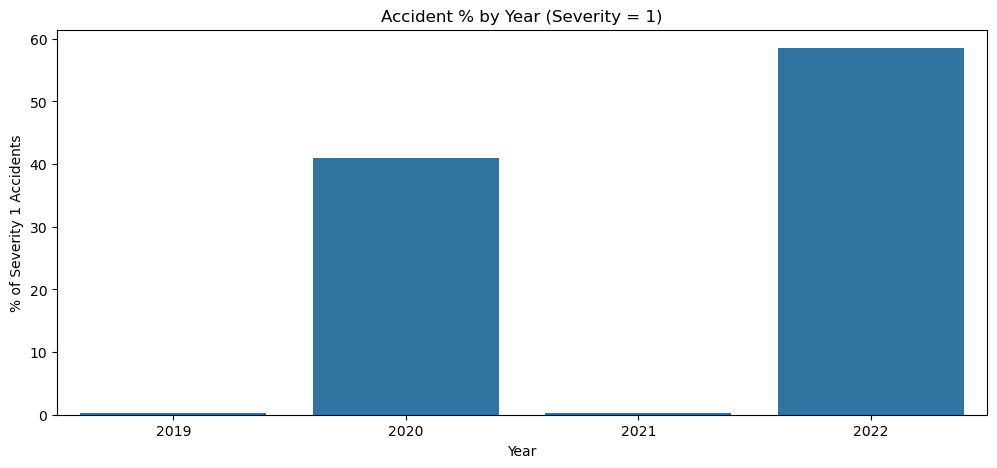

==================== Accident % by Month (Severity = 1) ====================


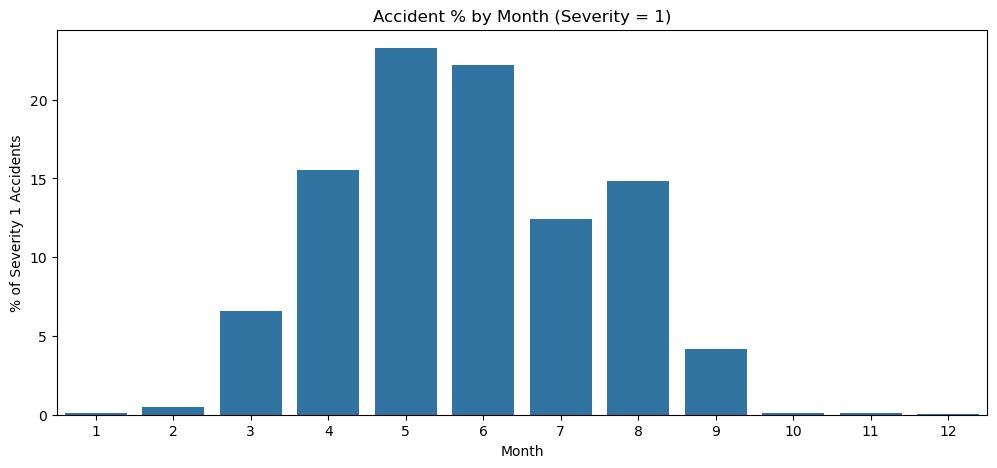

==================== Accident % by Hour (Severity = 1) ====================


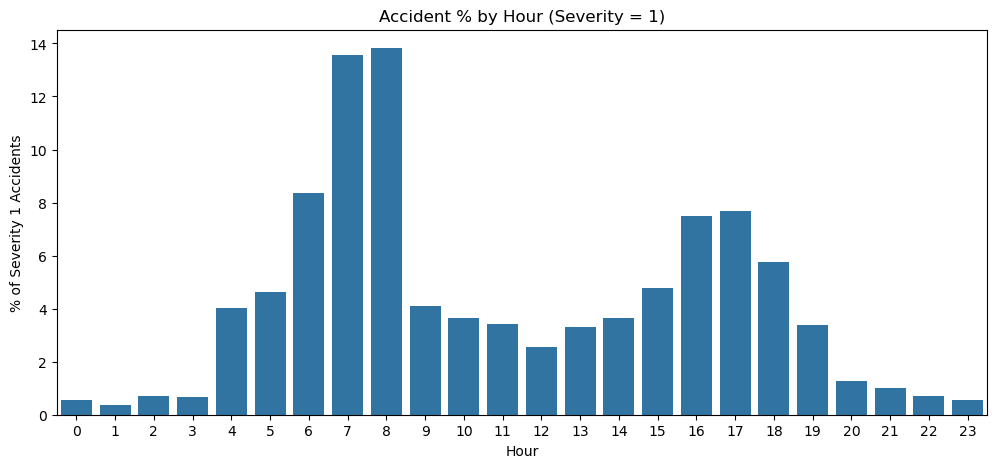

==================== Accident % by Weekend (Severity = 1) ====================


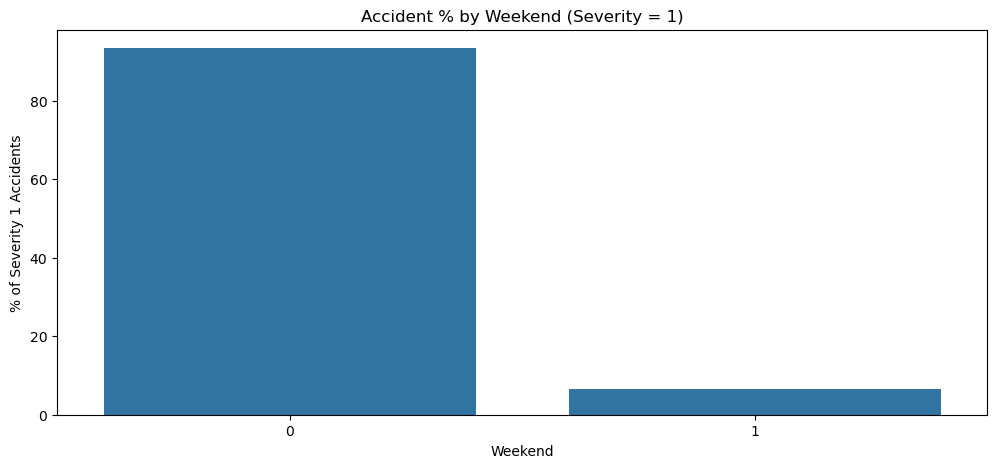

==================== Accident % by Year (Severity = 2) ====================


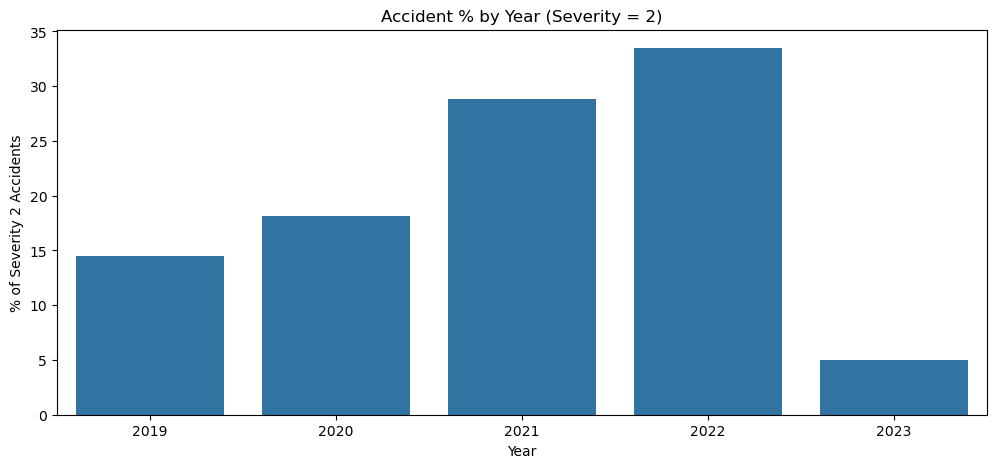

==================== Accident % by Month (Severity = 2) ====================


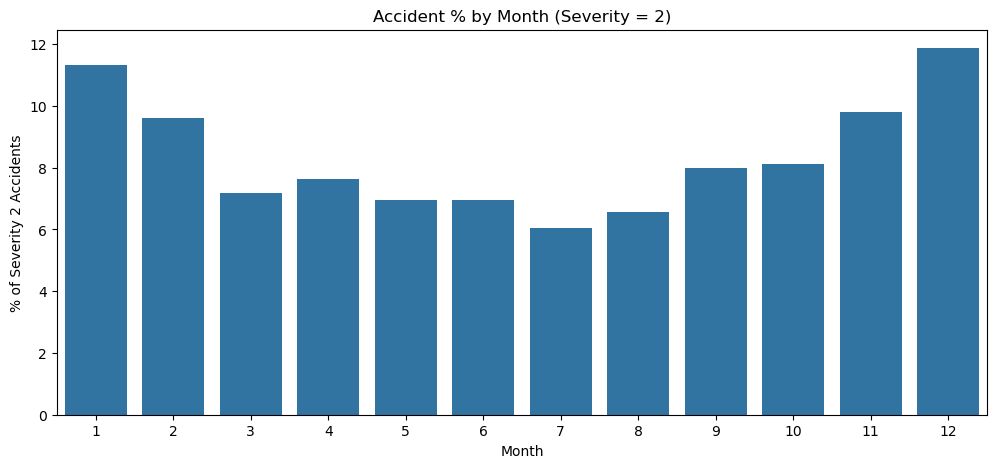

==================== Accident % by Hour (Severity = 2) ====================


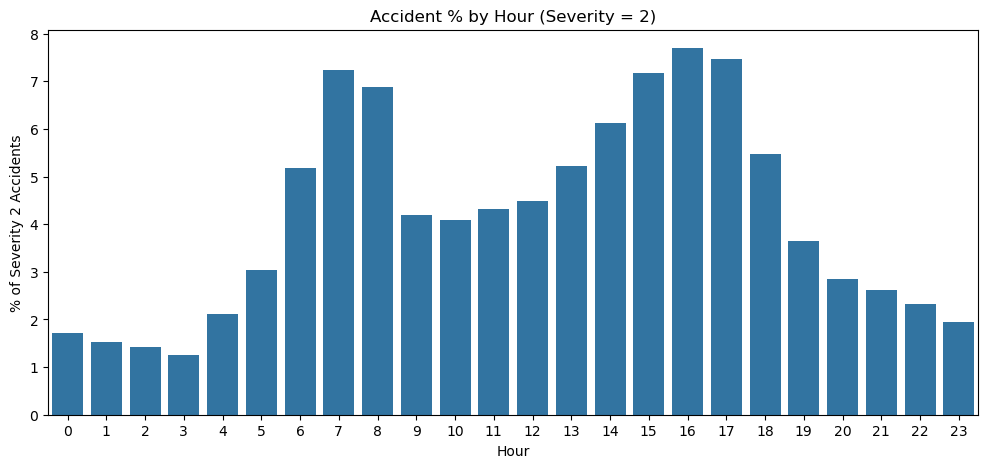

==================== Accident % by Weekend (Severity = 2) ====================


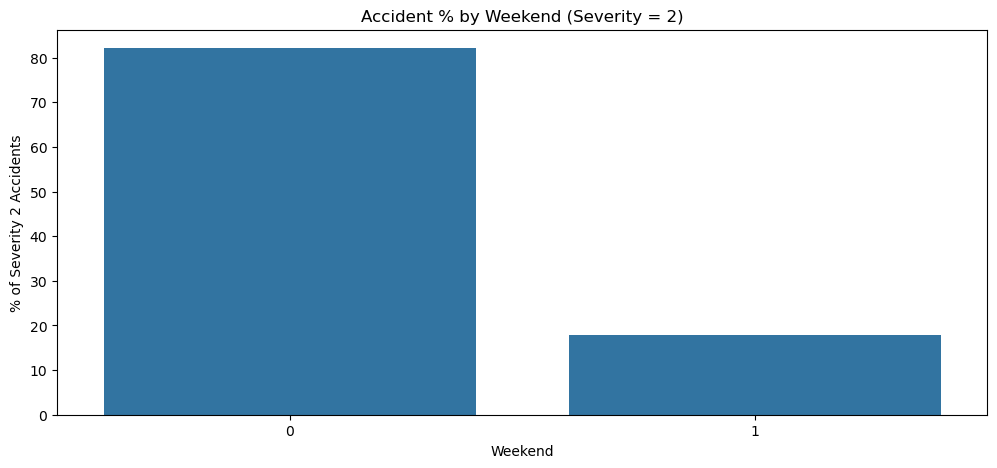

==================== Accident % by Year (Severity = 3) ====================


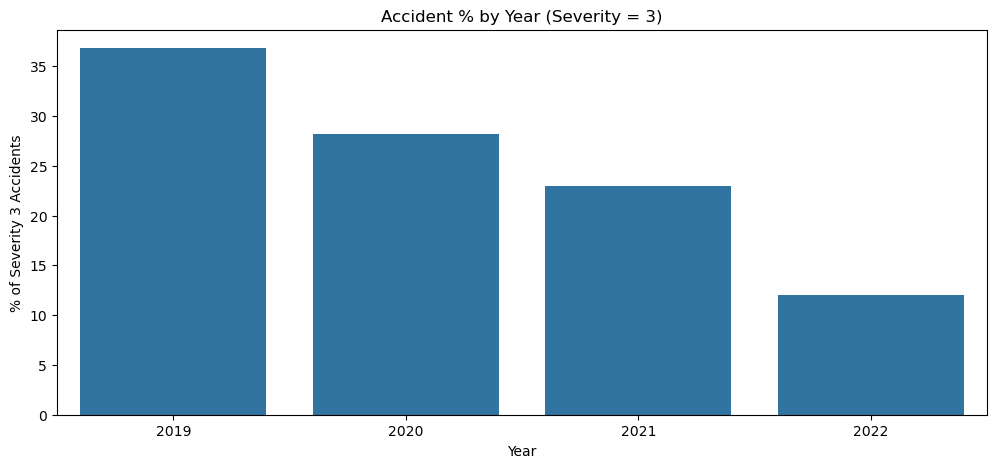

==================== Accident % by Month (Severity = 3) ====================


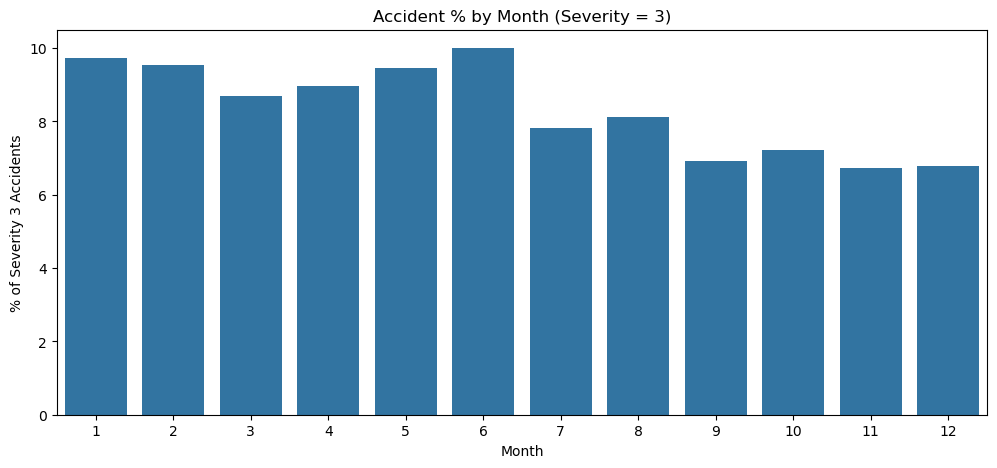

==================== Accident % by Hour (Severity = 3) ====================


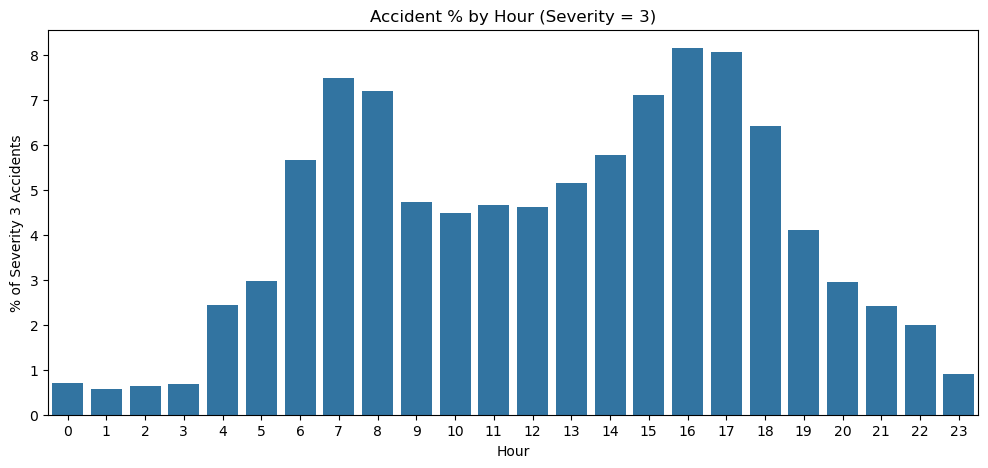

==================== Accident % by Weekend (Severity = 3) ====================


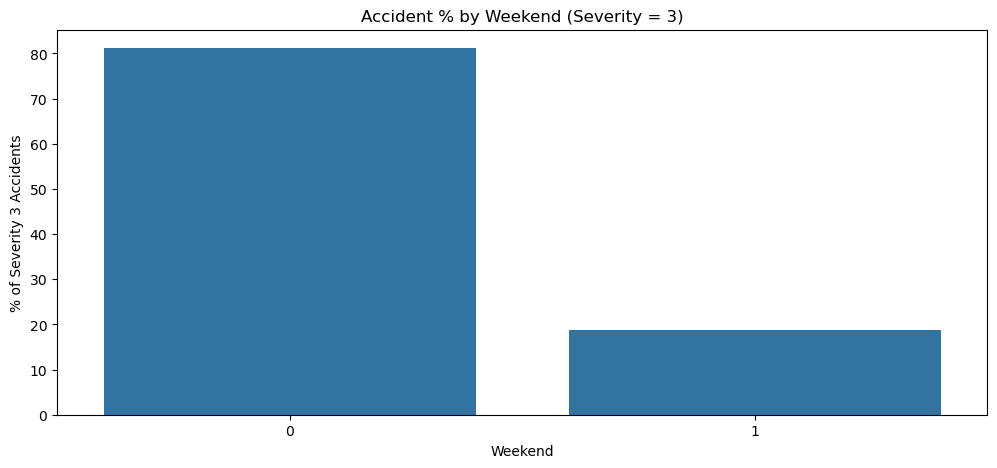

==================== Accident % by Year (Severity = 4) ====================


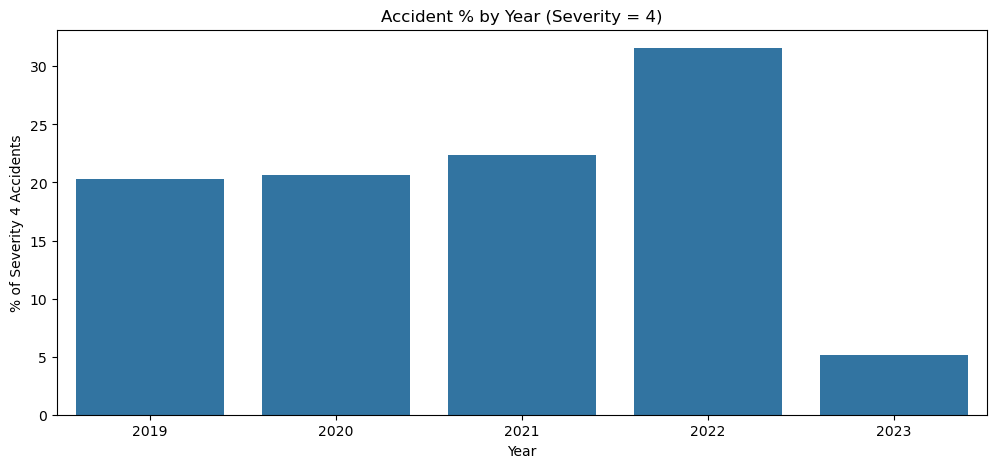

==================== Accident % by Month (Severity = 4) ====================


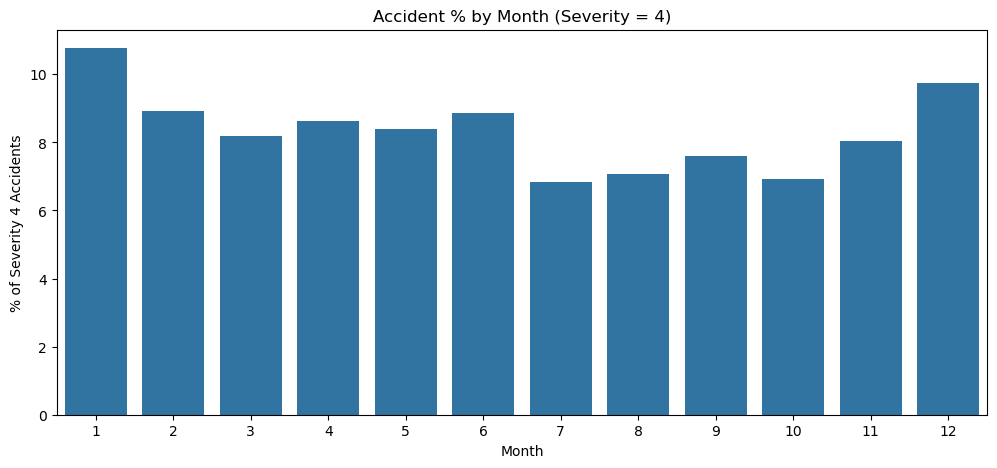

==================== Accident % by Hour (Severity = 4) ====================


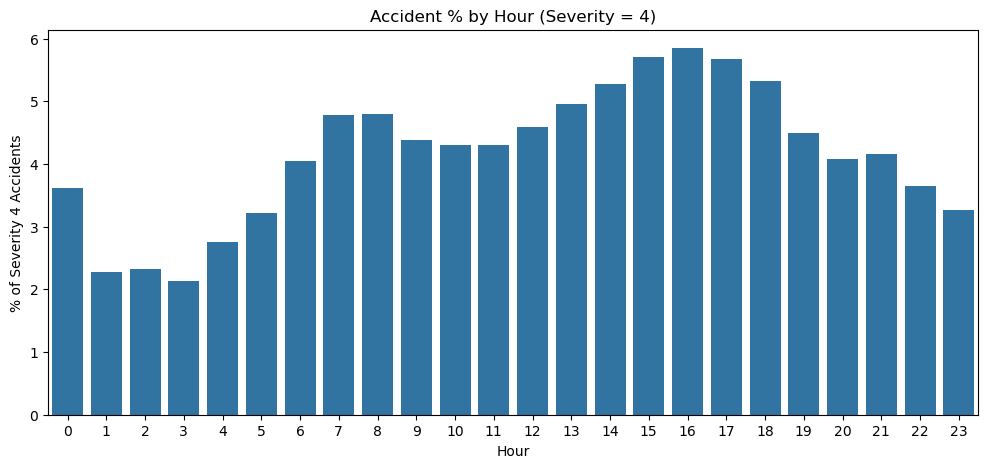

==================== Accident % by Weekend (Severity = 4) ====================


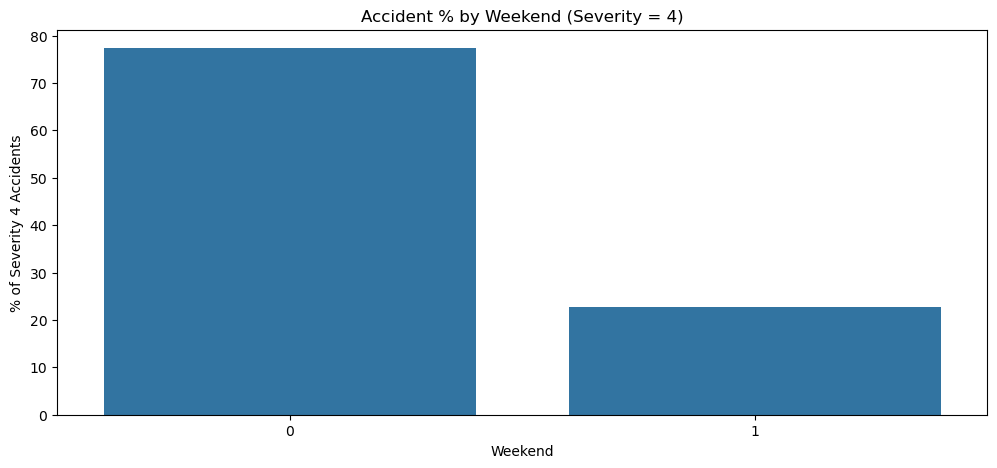

In [27]:
for severity in sorted(unique_severity):
    filtered_df = df.filter(F.col("Severity") == severity)
    total = filtered_df.count()

    for col_name, label in [
        ("Start_Time_Year", "Year"),
        ("Start_Time_Month", "Month"),
        ("Start_Time_Hour", "Hour"),
        ("Start_Time_is_Weekend", "Weekend")
    ]:
        grouped = filtered_df.groupBy(col_name).count() \
            .withColumn("pct", F.col("count") / total * 100) \
            .orderBy(col_name).toPandas()

        border(f"Accident % by {label} (Severity = {severity})")
        plt.figure(figsize=(12, 5))
        sns.barplot(data=grouped, x=col_name, y="pct")
        plt.xlabel(label)
        plt.ylabel(f"% of Severity {severity} Accidents")
        plt.title(f"Accident % by {label} (Severity = {severity})")
        plt.show()

### Plotting Accident Counts by Time-based Features (Not grouped by Severity)

==================== Start_Time_Year ====================


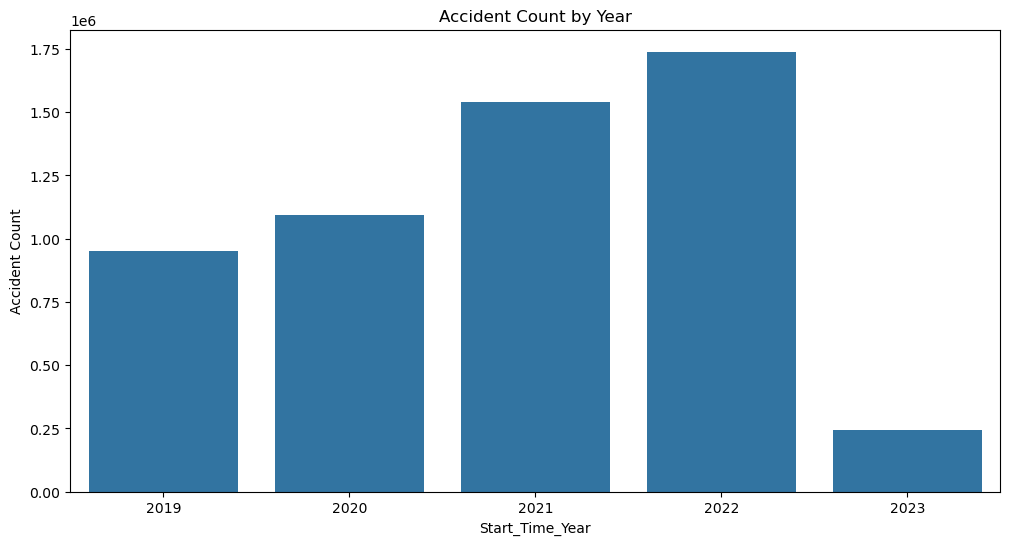


==================== Start_Time_Month ====================


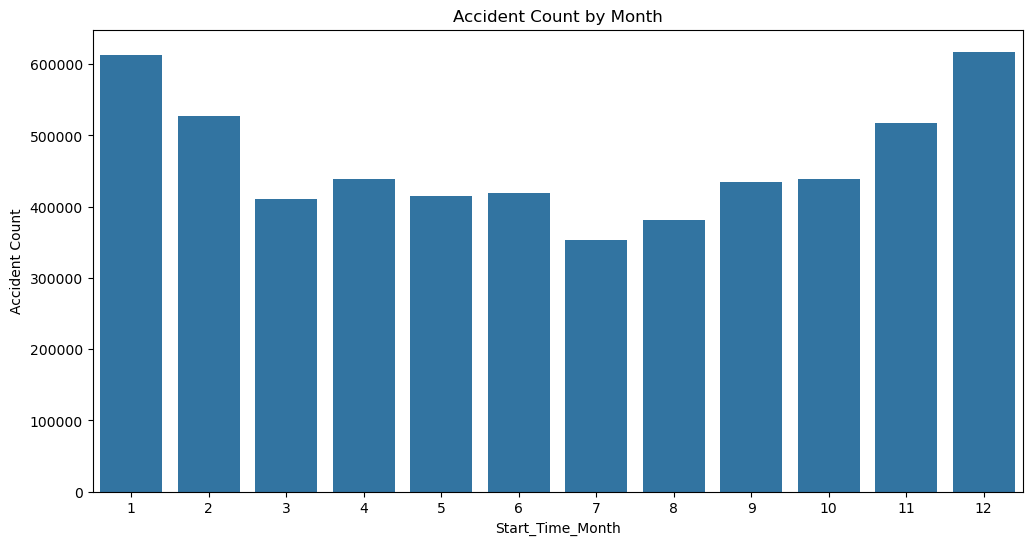


==================== Start_Time_Hour ====================


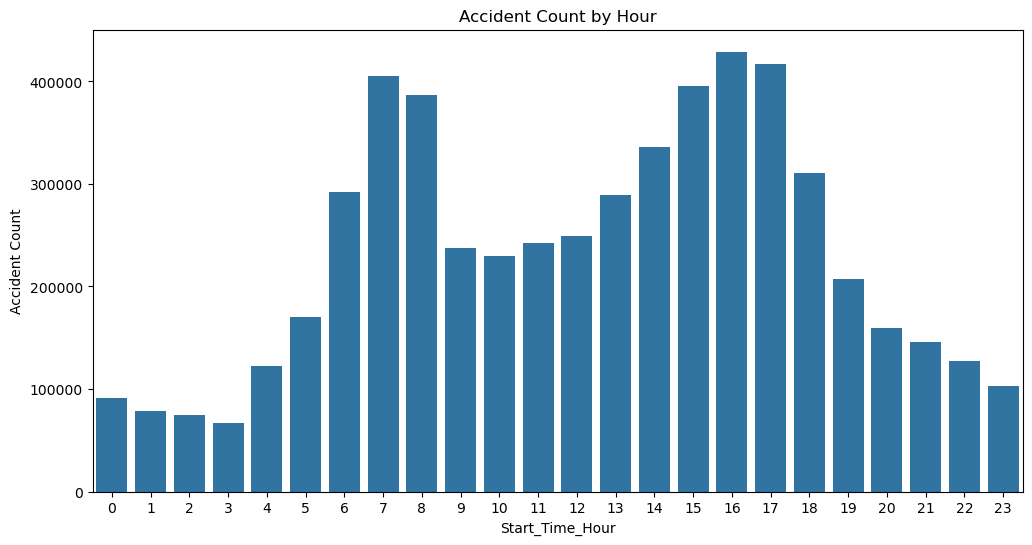


==================== Start_Time_Year & Start_Time_Month ====================


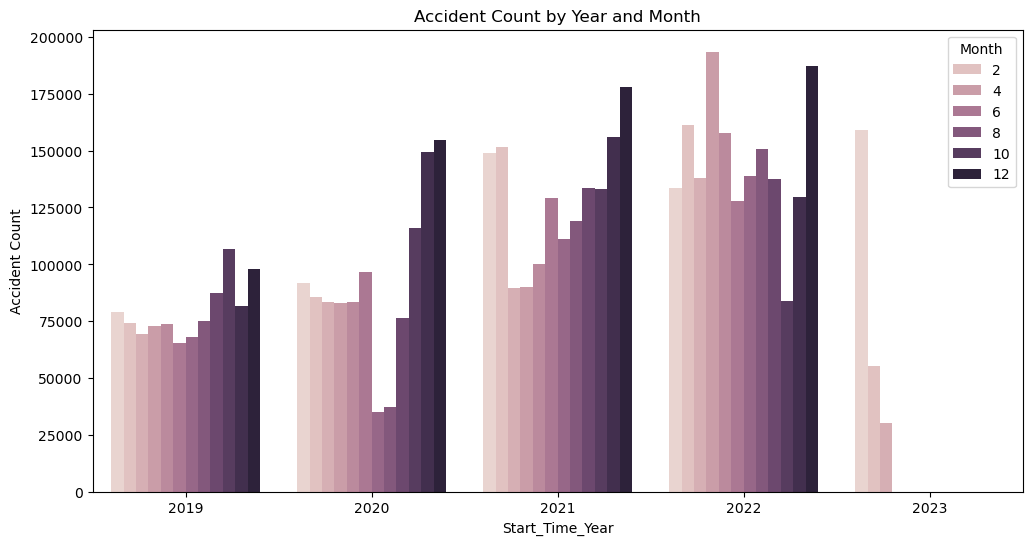


==================== Start_Time_Year, Start_Time_Month & Start_Time_Hour ====================


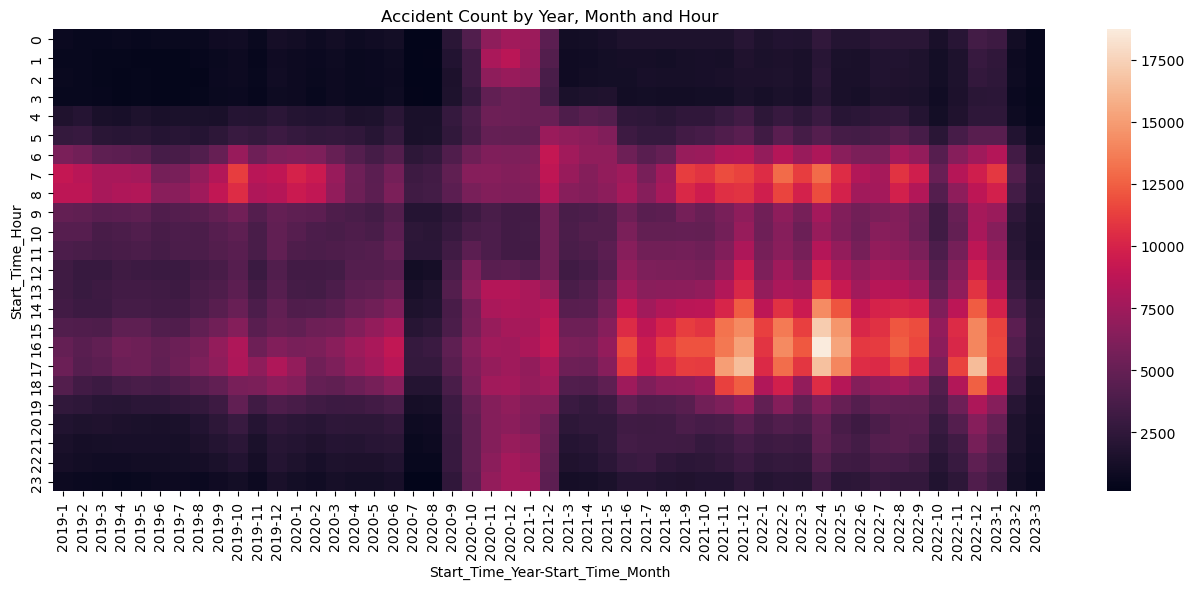


==================== Start_Time_is_Weekend ====================


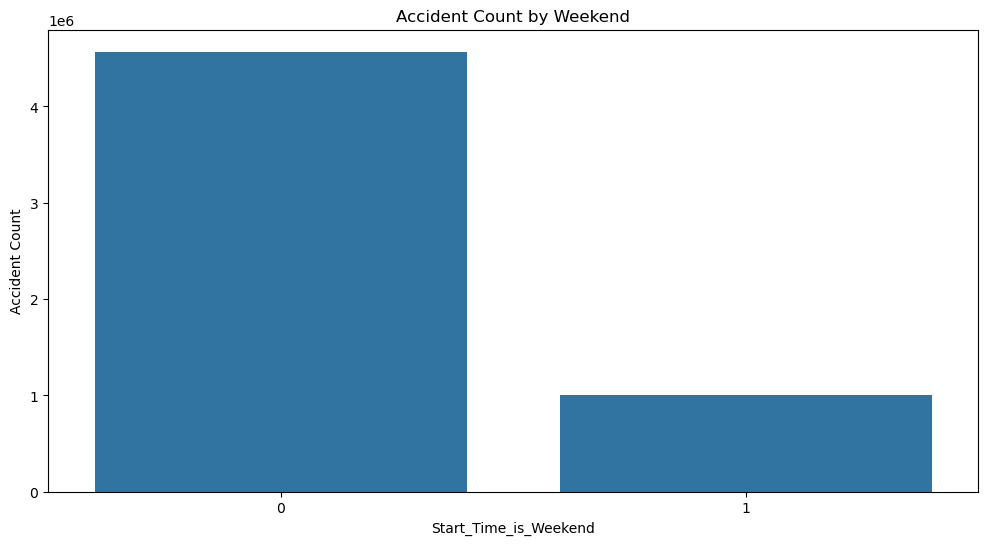

In [28]:
grouped_by_year = df.groupBy("Start_Time_Year").count().toPandas()
grouped_by_month = df.groupBy("Start_Time_Month").count().toPandas()
grouped_by_hour = df.groupBy("Start_Time_Hour").count().toPandas()
grouped_by_year_month = df.groupBy("Start_Time_Year", "Start_Time_Month").count().toPandas()
grouped_by_year_month_hour = df.groupBy("Start_Time_Year", "Start_Time_Month", "Start_Time_Hour").count().toPandas()
grouped_by_weekend = df.groupBy("Start_Time_is_Weekend").count().toPandas()

# Plot for Start_Time_Year
border("Start_Time_Year")
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_by_year, x="Start_Time_Year", y="count")
plt.xlabel("Start_Time_Year")
plt.ylabel("Accident Count")
plt.title("Accident Count by Year")
plt.show()

# Plot for Start_Time_Month
print()
border("Start_Time_Month")
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_by_month, x="Start_Time_Month", y="count")
plt.xlabel("Start_Time_Month")
plt.ylabel("Accident Count")
plt.title("Accident Count by Month")
plt.show()

# Plot for Start_Time_Hour
print()
border("Start_Time_Hour")
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_by_hour, x="Start_Time_Hour", y="count")
plt.xlabel("Start_Time_Hour")
plt.ylabel("Accident Count")
plt.title("Accident Count by Hour")
plt.show()

# Plotting Year and Month together
print()
border("Start_Time_Year & Start_Time_Month")
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_by_year_month, x="Start_Time_Year", y="count", hue="Start_Time_Month")
plt.xlabel("Start_Time_Year")
plt.ylabel("Accident Count")
plt.title("Accident Count by Year and Month")
plt.legend(title="Month", loc="upper right")
plt.show()

# Plotting Year, Month and Hour together
print()
border("Start_Time_Year, Start_Time_Month & Start_Time_Hour")
pivot = grouped_by_year_month_hour.pivot_table(
    index="Start_Time_Hour",
    columns=["Start_Time_Year", "Start_Time_Month"],
    values="count",
    fill_value=0
)
plt.figure(figsize=(16, 6))
sns.heatmap(pivot)
plt.title("Accident Count by Year, Month and Hour")
plt.show()

# Plot for Start_Time_is_Weekend
print()
border("Start_Time_is_Weekend")
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_by_weekend, x="Start_Time_is_Weekend", y="count")
plt.xlabel("Start_Time_is_Weekend")
plt.ylabel("Accident Count")
plt.title("Accident Count by Weekend")
plt.show()

## Standardising Wind_Direction

In [29]:
# Print all unique values and their counts in terms of dict
def get_count(df):
    counts_df = df.groupBy("Wind_Direction").agg(F.count("*").alias("count"))
    counts_dict = {row["Wind_Direction"]: row["count"] for row in counts_df.collect()}
    total_count = df.count()

    return counts_dict, total_count

before_dict, before_total = get_count(df)

border("BEFORE")
print(before_dict)
print("Total count:", before_total)

# Standardise into N, S, E, W, NE, SE, NW, SW, CALM, VAR
df = df.withColumn(
    "Wind_Direction",
    F.when(F.col("Wind_Direction") == "Calm", "CALM")
    .when(F.col("Wind_Direction").isin("North", "NNE", "NNW"), "N")
    .when(F.col("Wind_Direction").isin("East", "ENE", "ESE"), "E")
    .when(F.col("Wind_Direction").isin("South", "SSE", "SSW"), "S")
    .when(F.col("Wind_Direction").isin("West", "WNW", "WSW"), "W")
    .when(F.col("Wind_Direction") == "Variable", "VAR")
    .otherwise(F.col("Wind_Direction"))
)

# Drop remaining null values
df = df.dropna(subset="Wind_Direction")

after_dict, after_total = get_count(df)

print()
border("AFTER")
print(after_dict)
print("Total count:", after_total)
print("\nRow dropped:", before_total - after_total)

==================== BEFORE ====================
{'VAR': 244429, None: 145004, 'SSE': 248568, 'S': 409439, 'N': 298081, 'CALM': 930755, 'SE': 214284, 'West': 15513, 'ESE': 198083, 'South': 16128, 'WNW': 271649, 'SW': 259145, 'East': 11812, 'Calm': 36977, 'W': 374088, 'NNW': 244812, 'Variable': 8776, 'NNE': 183447, 'North': 17699, 'NW': 268380, 'WSW': 253820, 'SSW': 272156, 'E': 270755, 'NE': 185852, 'ENE': 188395}
Total count: 5568047

==================== AFTER ====================
{'VAR': 253205, 'S': 946291, 'N': 744039, 'CALM': 967732, 'SE': 214284, 'SW': 259145, 'W': 915070, 'NW': 268380, 'E': 669045, 'NE': 185852}
Total count: 5423043

Row dropped: 145004


The original `Wind_Direction` feature exhibits high cardinality with redundant labels such as "North" and "N" as well as hyper-specific sub-directions like North-Northeast "NNE". By merging synonymous terms and grouping third-degree directions into their second-degree parents, we simplify the feature space without losing meaningful meteorological context. This consolidation prevents the model from treating identical directions as distinct categories and reduces the risk of overfitting to specific wind angles that likely have a marginal impact on accident severity.

## Handling missing values

- Impute missing values for:
  1. Temperature(F)
  2. Humidity(%)
  3. Pressure(in)
  4. Visibility(mi)
  5. Wind_Speed(mph)
  6. Precipitation(in)

In [30]:
# Print missing values from weather data
def show_missing_weather(df, weather, label):
    border(label)
    df.select([
        F.sum((F.col(c).isNull() | F.isnan(F.col(c))).cast("int")).alias(c)
        for c in weather
    ]).show()

# Create list of weather data
weather = ["Temperature(F)","Humidity(%)","Pressure(in)","Visibility(mi)","Wind_Speed(mph)", "Precipitation(in)"]

show_missing_weather(df, weather, "BEFORE")

# Impute missing values with median based on Airport_Code and Start_Time_Month
median_df = df.groupBy("Airport_Code", "Start_Time_Month").agg(
    *[F.median(F.col(c)).alias(f"{c}_median") for c in weather]
)
df = df.join(median_df, on=["Airport_Code", "Start_Time_Month"], how="left")
for c in weather:
    df = df.withColumn(c, F.coalesce(F.col(c), F.col(f"{c}_median")))

df = df.drop(*[f"{c}_median" for c in weather])
df = df.dropna(subset=weather)

show_missing_weather(df, weather, "AFTER")

==================== BEFORE ====================
+--------------+-----------+------------+--------------+---------------+-----------------+
|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Speed(mph)|Precipitation(in)|
+--------------+-----------+------------+--------------+---------------+-----------------+
|         18089|      25926|        5327|         18538|          40009|           321687|
+--------------+-----------+------------+--------------+---------------+-----------------+

==================== AFTER ====================
+--------------+-----------+------------+--------------+---------------+-----------------+
|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Speed(mph)|Precipitation(in)|
+--------------+-----------+------------+--------------+---------------+-----------------+
|             0|          0|           0|             0|              0|                0|
+--------------+-----------+------------+--------------+---------------+-----------

Weather conditions are intrinsically linked to specific geographic locations and seasonal cycles. Imputing missing numerical values using the **median** grouped by `Airport_Code` and `Start_Time_Month` ensures that the substituted data reflects the micro-climate of the incident area.

Since it is stated that traffic weather data is collected from airport-based sensors, using the `Airport_Code` provides the most accurate proxy for the local weather condition. Furthermore, incorporating the `Start_Time_Month` captures seasonal variations that a global imputation would overlook. Lastly, using the median within these specific groups provides a representative value that is resistant to extreme weather anomalies.

## Drop Remaining NA rows

In [31]:
# Drop NA rows for City, Zipcode, Airport_Code, Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight
# modify it --> if num NA rows <500k --> drop NAs for that column
bef_drop_n = df.count()
df = df.dropna(
    subset=['City', 'Zipcode', 'Airport_Code', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Street', 'Weather_Condition']
)
aft_drop_n = df.count()

df.printSchema()

print()
border("BEFORE")
print(bef_drop_n)

border("AFTER")
print(aft_drop_n)

print("Rows dropped:", bef_drop_n - aft_drop_n)

root
 |-- Airport_Code: string (nullable = true)
 |-- Start_Time_Month: integer (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Wind_Direction: string (nullable = true)
 |-- Wind_Speed(mph): double (nullable = true)
 |-- Precipitation(in): double (nullable = true)
 |-- Weather_Condition: string (nullable = true)
 |-- Amenity: boolean (nullable = true)
 |-- Bump

## Visualisations for Accident Counts

### Define Window and Find Number of Unique Severities

In [32]:
window_sev = Window.partitionBy("Severity")
unique_severity = [row["Severity"] for row in df.select("Severity").distinct().collect()]

### Accident Count by State

==================== Accident % by State (Severity = 1) ====================


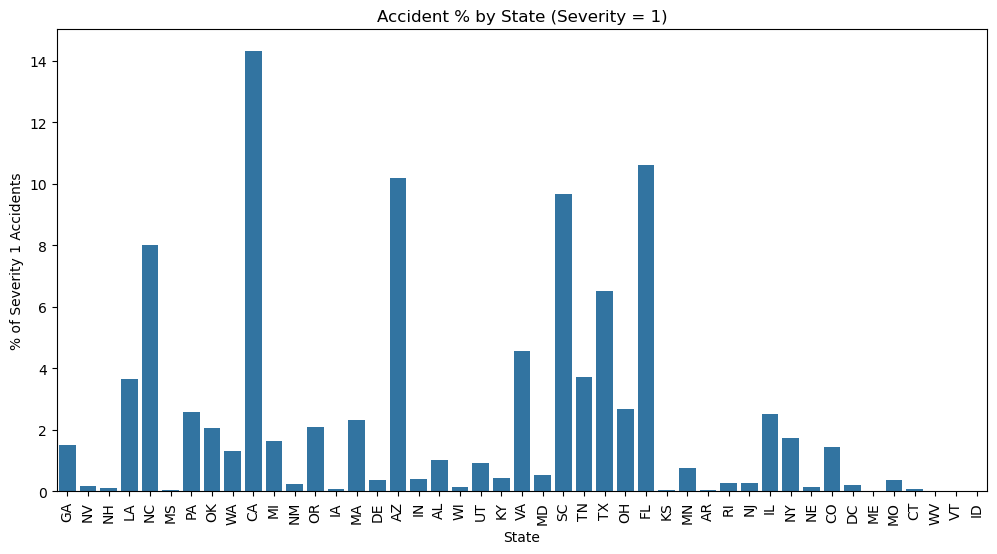

==================== Accident % by State (Severity = 2) ====================


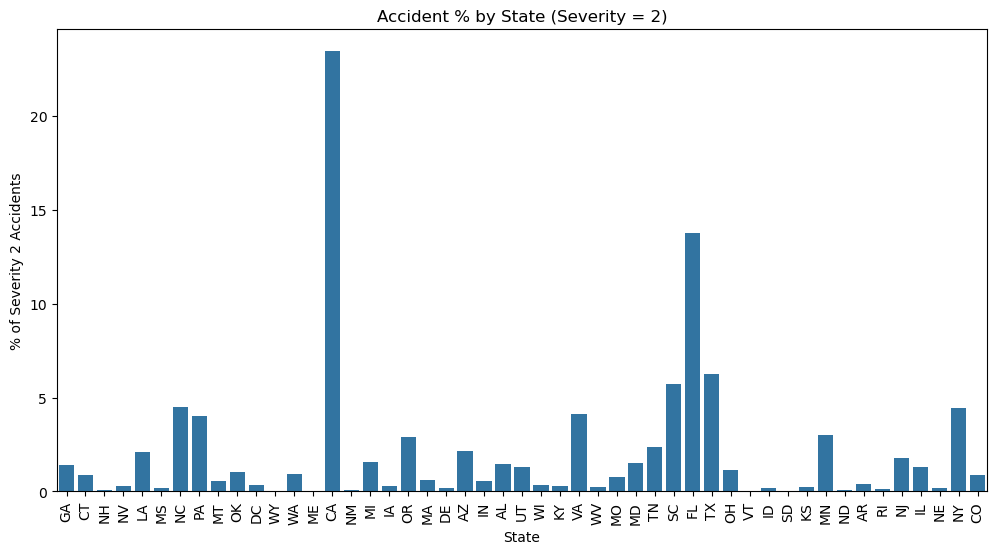

==================== Accident % by State (Severity = 3) ====================


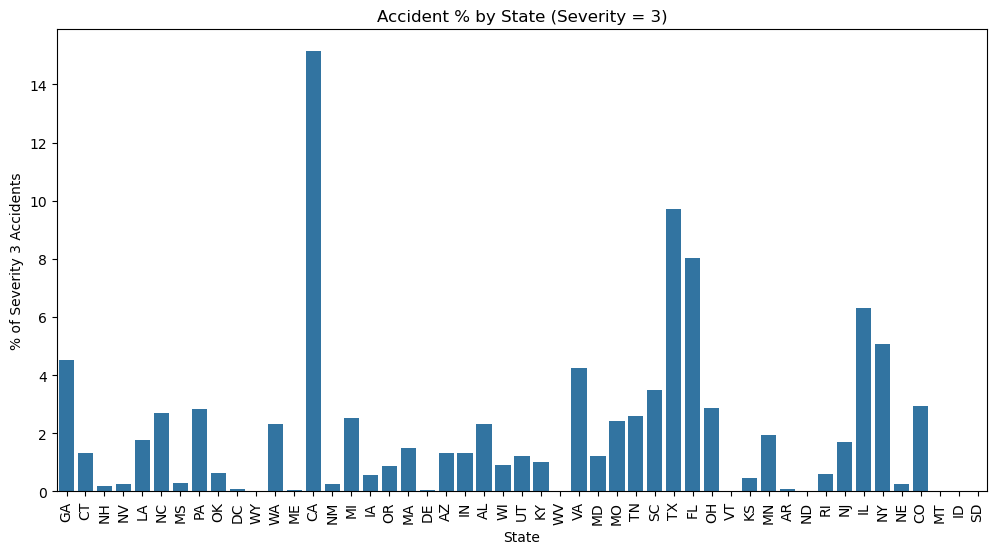

==================== Accident % by State (Severity = 4) ====================


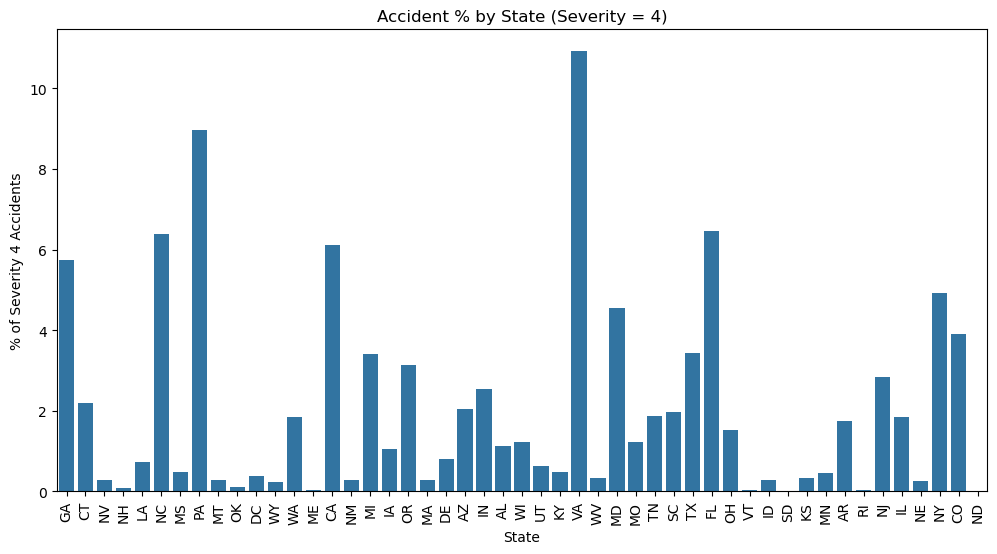

In [33]:
for severity in sorted(unique_severity):
    filtered_df = df.filter(F.col("Severity") == severity)
    
    w = Window.partitionBy()
    total = filtered_df.count()
    grouped = filtered_df.groupBy("State").count() \
        .withColumn("pct", F.col("count") / total * 100) \
        .toPandas()

    border(f"Accident % by State (Severity = {severity})")
    plt.figure(figsize=(12, 6))
    sns.barplot(data=grouped, x="State", y="pct")
    plt.xlabel("State")
    plt.ylabel(f"% of Severity {severity} Accidents")
    plt.title(f"Accident % by State (Severity = {severity})")
    plt.xticks(rotation=90)
    plt.show()

### Accident Count by Longitude and Latitude


==================== Accident Count by Longitude and Latitude (Severity = 1) ====================


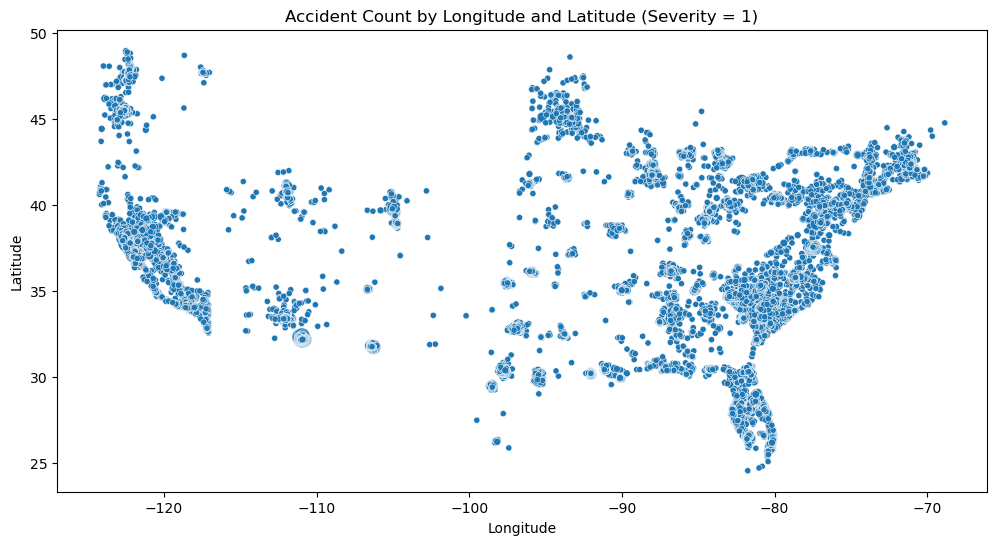


==================== Accident Count by Longitude and Latitude (Severity = 2) ====================


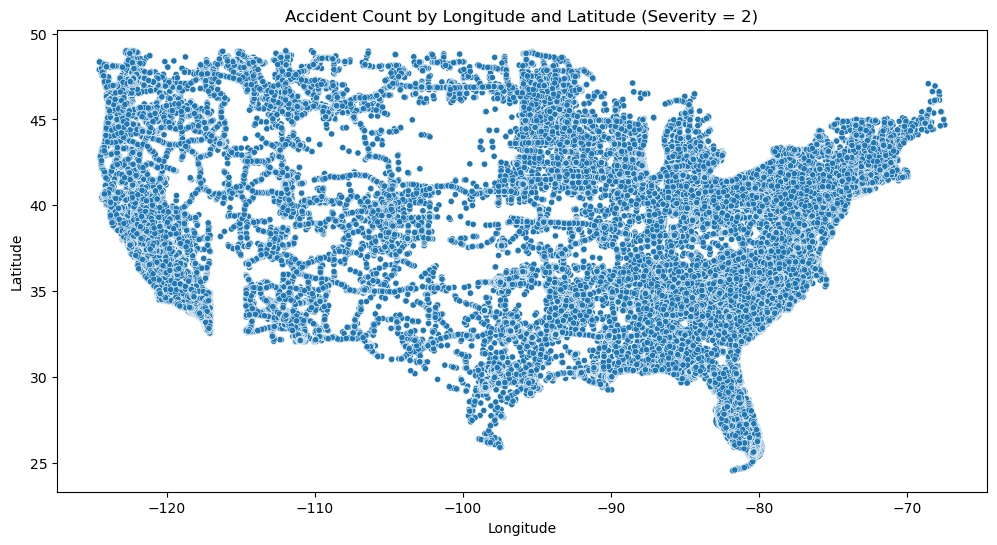


==================== Accident Count by Longitude and Latitude (Severity = 3) ====================


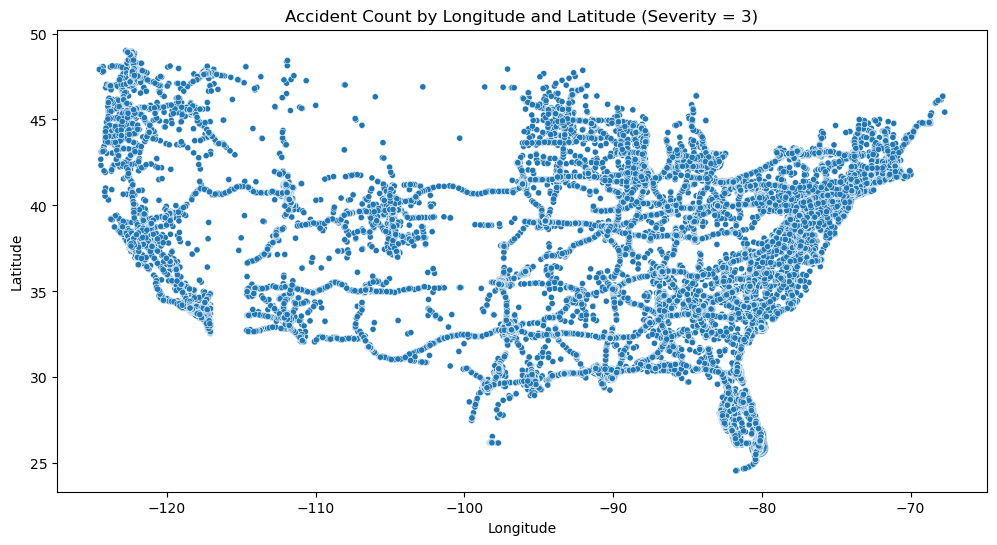


==================== Accident Count by Longitude and Latitude (Severity = 4) ====================


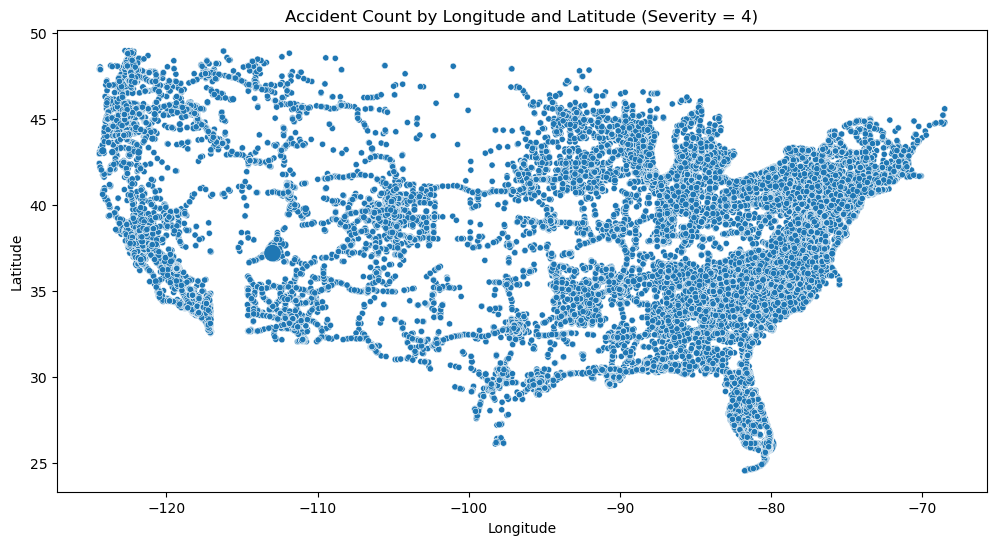

In [34]:
for severity in sorted(unique_severity):
    filtered_df = df.filter(F.col("Severity") == severity)
    grouped_by_longitude_latitude = filtered_df.groupBy("Start_Lng", "Start_Lat").count().toPandas()

    print()
    border(f"Accident Count by Longitude and Latitude (Severity = {severity})")
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=grouped_by_longitude_latitude, x="Start_Lng", y="Start_Lat", size="count", sizes=(20, 200), legend=None)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Accident Count by Longitude and Latitude (Severity = {severity})")
    plt.show()

### Accident Count by Weather Condition

==================== Accident % by Weather Condition (Severity = 1) ====================


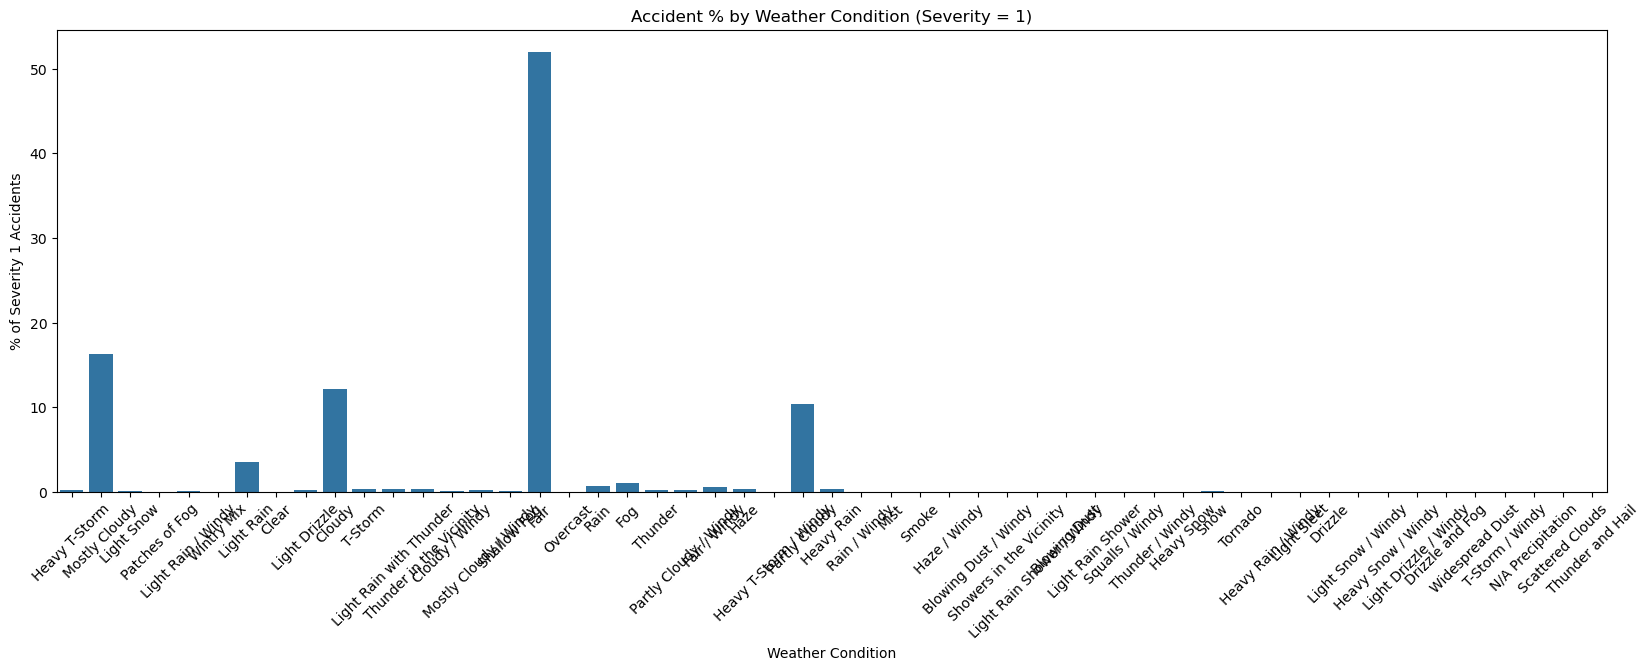

==================== Accident % by Weather Condition (Severity = 2) ====================


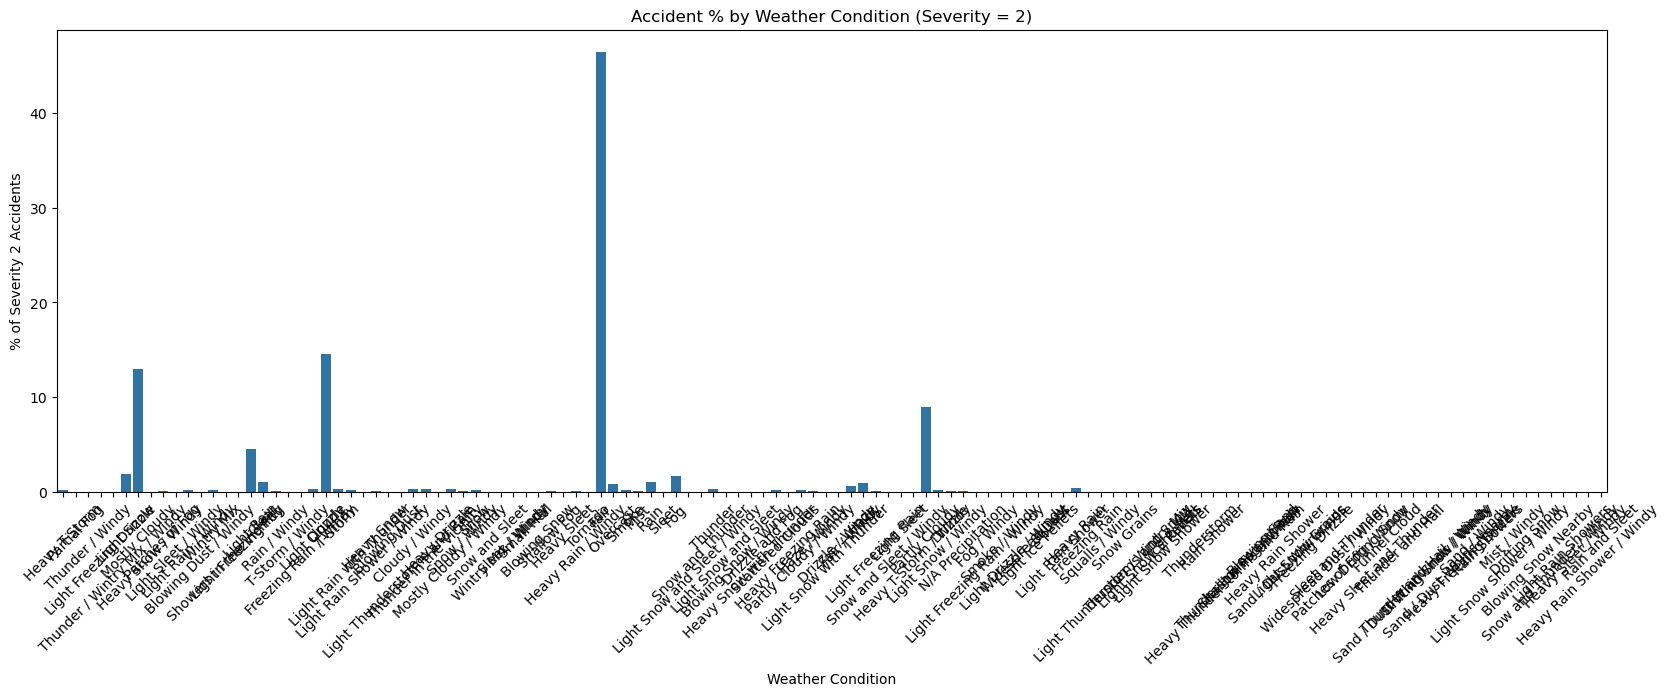

==================== Accident % by Weather Condition (Severity = 3) ====================


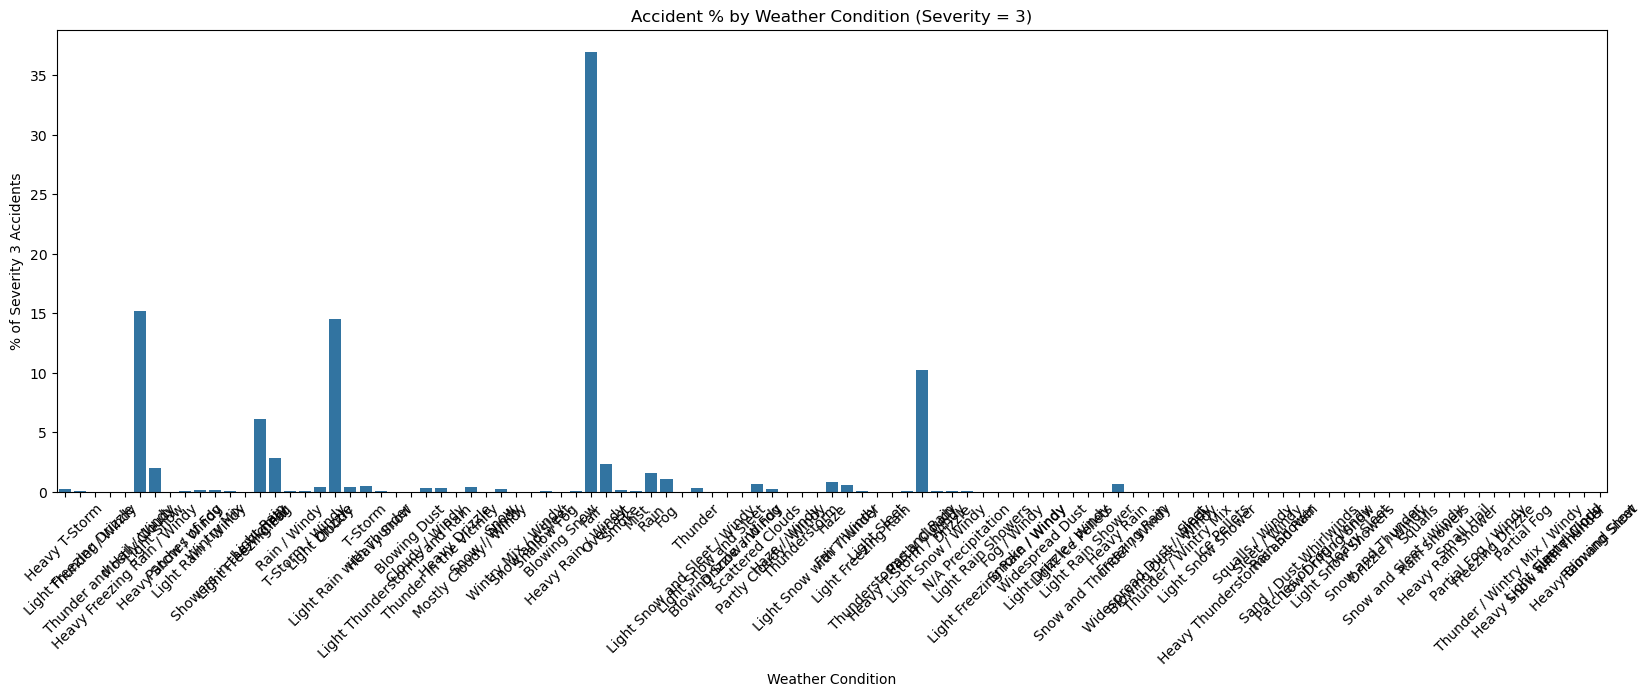

==================== Accident % by Weather Condition (Severity = 4) ====================


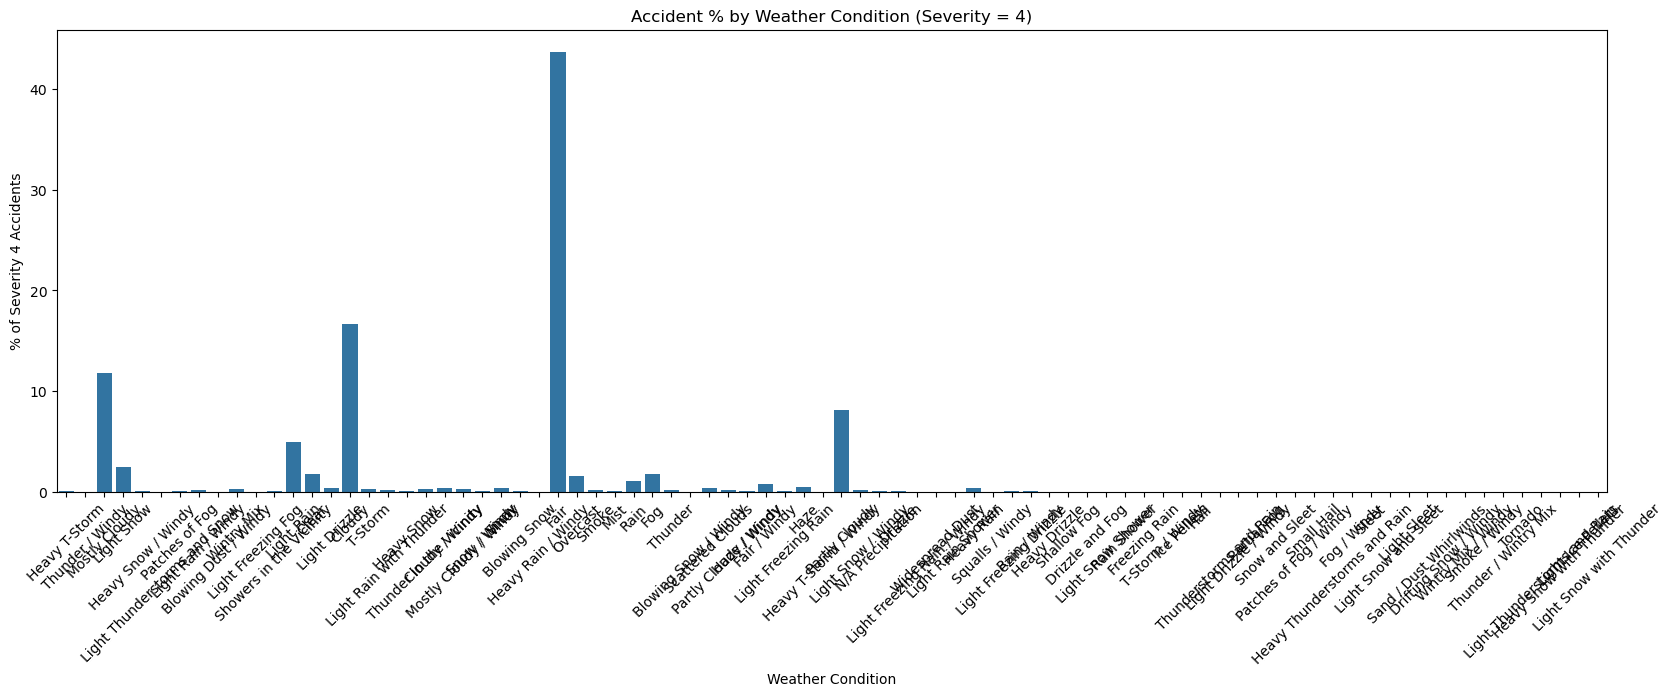

In [35]:
for severity in sorted(unique_severity):
    filtered_df = df.filter(F.col("Severity") == severity)
    total = filtered_df.count()
    grouped = filtered_df.groupBy("Weather_Condition").count() \
        .withColumn("pct", F.col("count") / total * 100) \
        .toPandas()

    border(f"Accident % by Weather Condition (Severity = {severity})")
    plt.figure(figsize=(20, 6))
    sns.barplot(data=grouped, x="Weather_Condition", y="pct")
    plt.xlabel("Weather Condition")
    plt.ylabel(f"% of Severity {severity} Accidents")
    plt.title(f"Accident % by Weather Condition (Severity = {severity})")
    plt.xticks(rotation=45)
    plt.show()

### Accident Count by Wind Direction

==================== Accident % by Wind Direction (Severity = 1) ====================


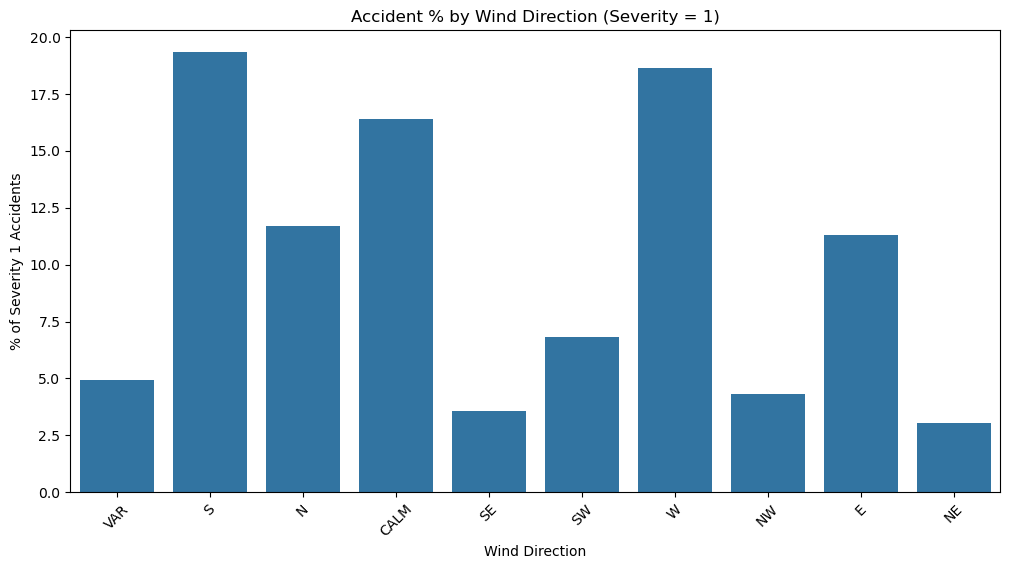

==================== Accident % by Wind Direction (Severity = 2) ====================


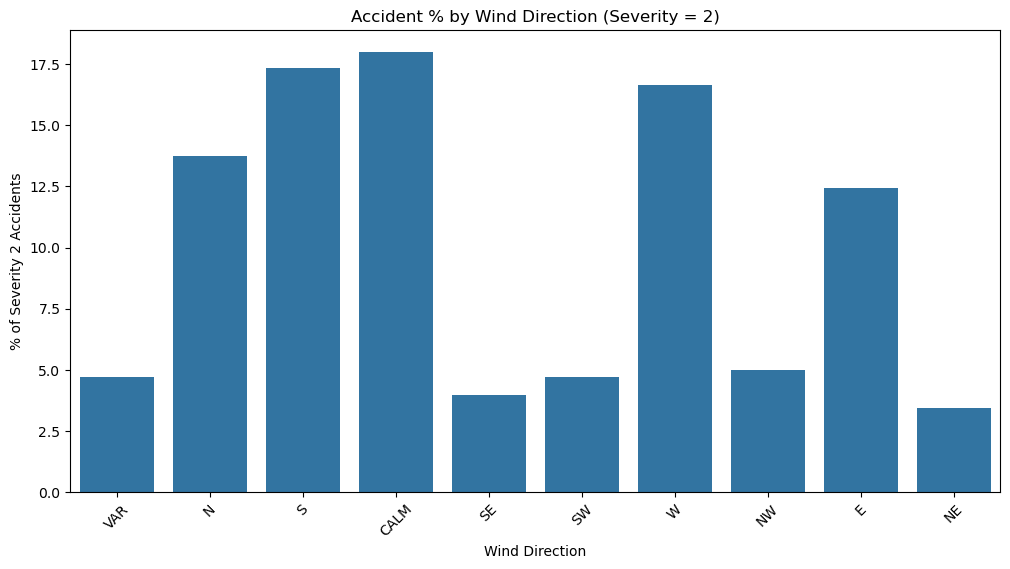

==================== Accident % by Wind Direction (Severity = 3) ====================


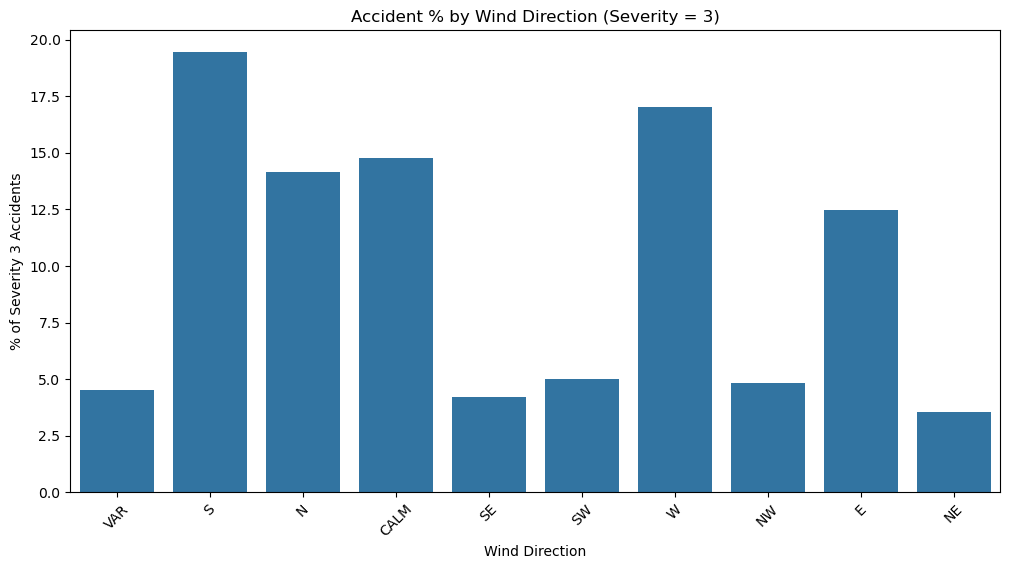

==================== Accident % by Wind Direction (Severity = 4) ====================


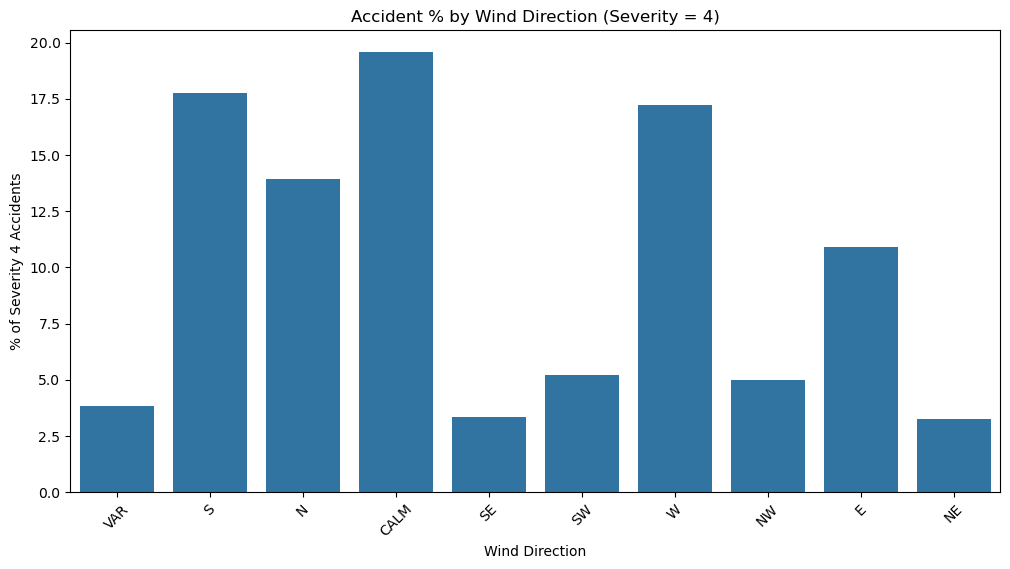

In [36]:
for severity in sorted(unique_severity):
    filtered_df = df.filter(F.col("Severity") == severity)
    total = filtered_df.count()
    grouped = filtered_df.groupBy("Wind_Direction").count() \
        .withColumn("pct", F.col("count") / total * 100) \
        .toPandas()

    border(f"Accident % by Wind Direction (Severity = {severity})")
    plt.figure(figsize=(12, 6))
    sns.barplot(data=grouped, x="Wind_Direction", y="pct")
    plt.xlabel("Wind Direction")
    plt.ylabel(f"% of Severity {severity} Accidents")
    plt.title(f"Accident % by Wind Direction (Severity = {severity})")
    plt.xticks(rotation=45)
    plt.show()

### Accident Count by POI Features

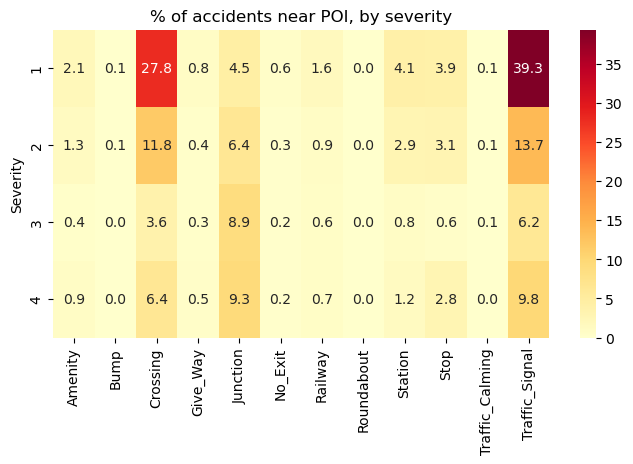

In [37]:
poi_columns = ["Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal"]

poi_rows = []
for severity in sorted(unique_severity):
    filtered_df = df.filter(F.col("Severity") == severity)
    total = filtered_df.count()
    row = {"Severity": severity}
    for poi in poi_columns:
        true_count = filtered_df.filter(F.col(poi) == True).count()
        row[poi] = true_count / total * 100
    poi_rows.append(row)

import pandas as pd
poi_pd = pd.DataFrame(poi_rows).set_index("Severity")

plt.figure(figsize=(8, 4))
sns.heatmap(poi_pd, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("% of accidents near POI, by severity")
plt.ylabel("Severity")
plt.show()

### Accident Count by POI Features (All Severities)

### Accident Count by Twilight Features

==================== Severity 1 ====================
==================== Accident % by Sunrise_Sunset (Severity = 1) ====================


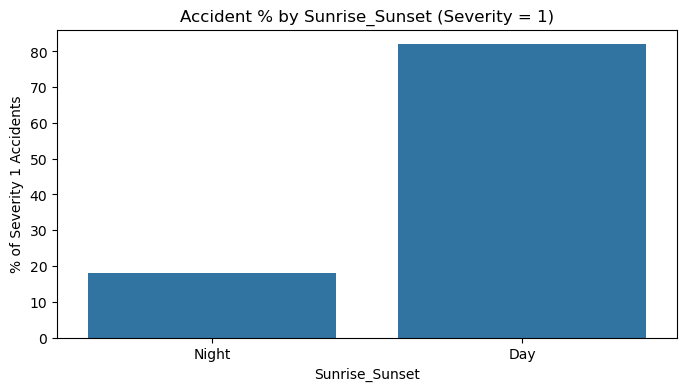

==================== Accident % by Civil_Twilight (Severity = 1) ====================


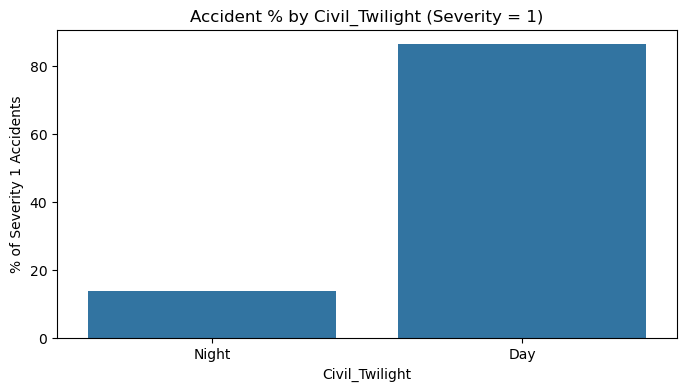

==================== Accident % by Nautical_Twilight (Severity = 1) ====================


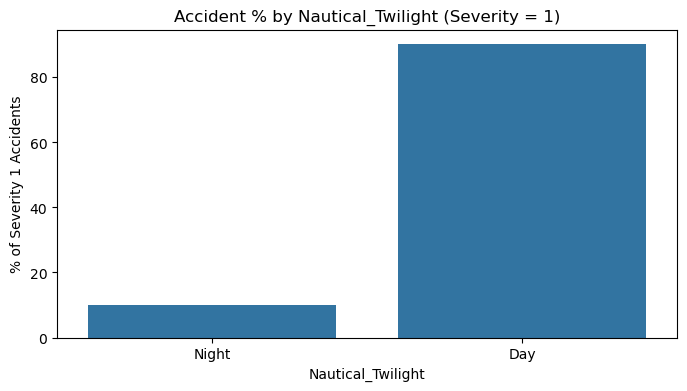

==================== Accident % by Astronomical_Twilight (Severity = 1) ====================


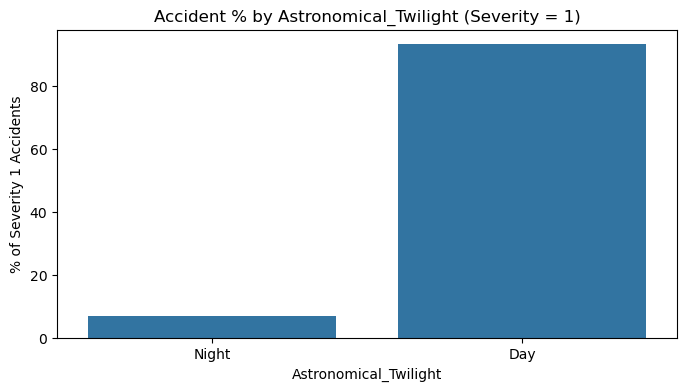

==================== Severity 2 ====================
==================== Accident % by Sunrise_Sunset (Severity = 2) ====================


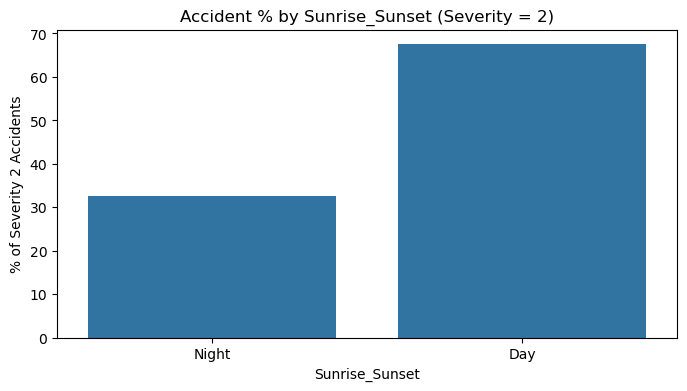

==================== Accident % by Civil_Twilight (Severity = 2) ====================


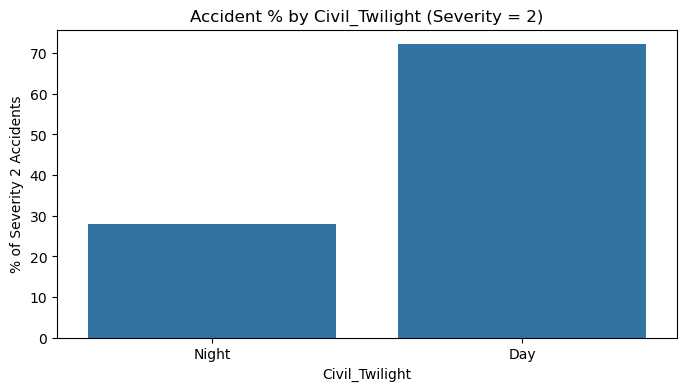

==================== Accident % by Nautical_Twilight (Severity = 2) ====================


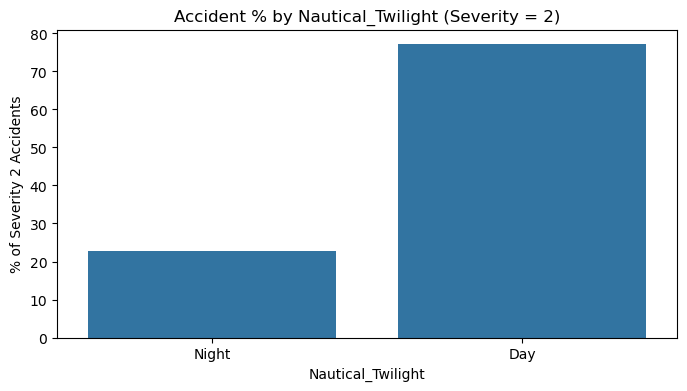

==================== Accident % by Astronomical_Twilight (Severity = 2) ====================


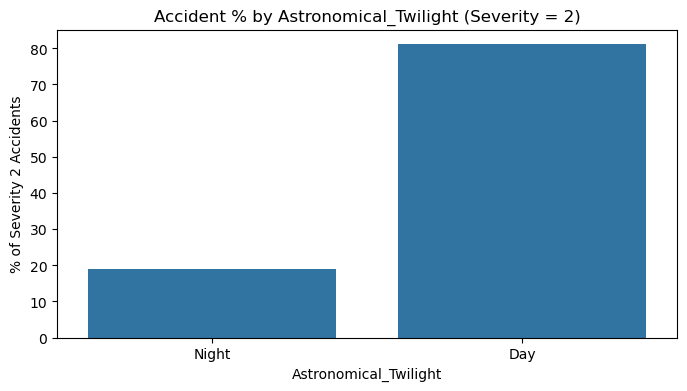

==================== Severity 3 ====================
==================== Accident % by Sunrise_Sunset (Severity = 3) ====================


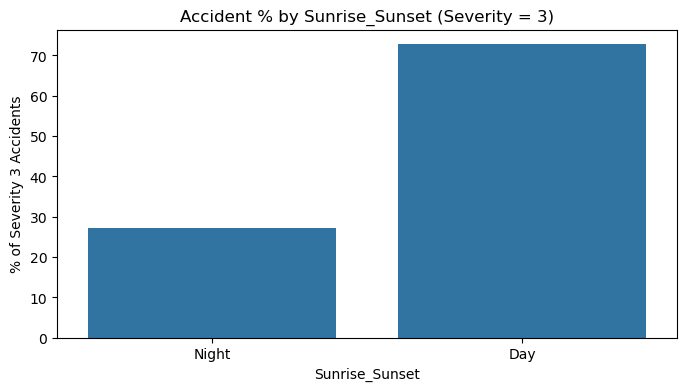

==================== Accident % by Civil_Twilight (Severity = 3) ====================


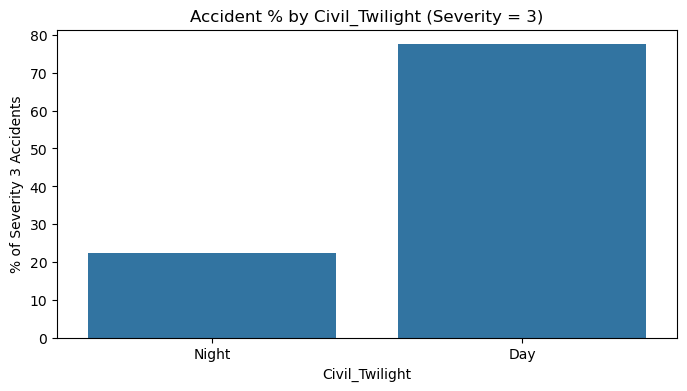

==================== Accident % by Nautical_Twilight (Severity = 3) ====================


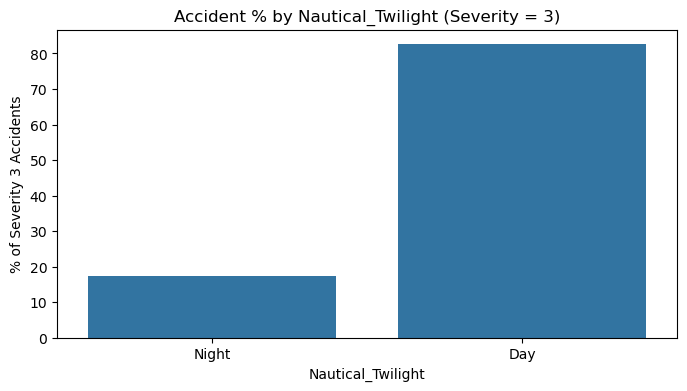

==================== Accident % by Astronomical_Twilight (Severity = 3) ====================


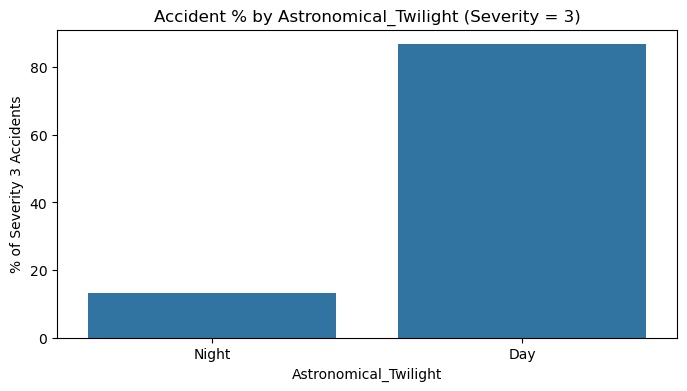

==================== Severity 4 ====================
==================== Accident % by Sunrise_Sunset (Severity = 4) ====================


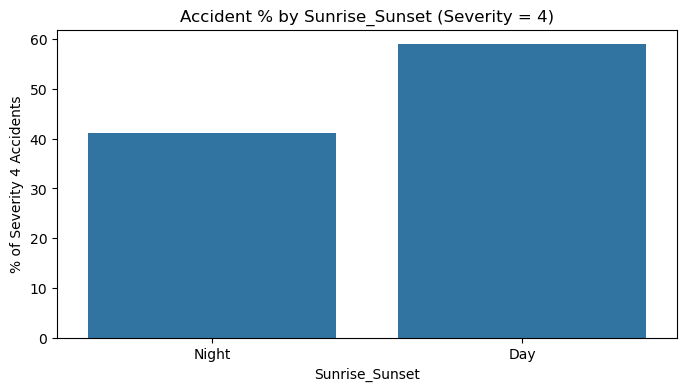

==================== Accident % by Civil_Twilight (Severity = 4) ====================


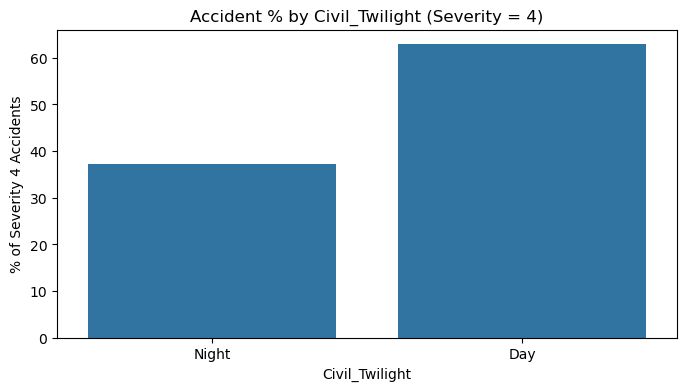

==================== Accident % by Nautical_Twilight (Severity = 4) ====================


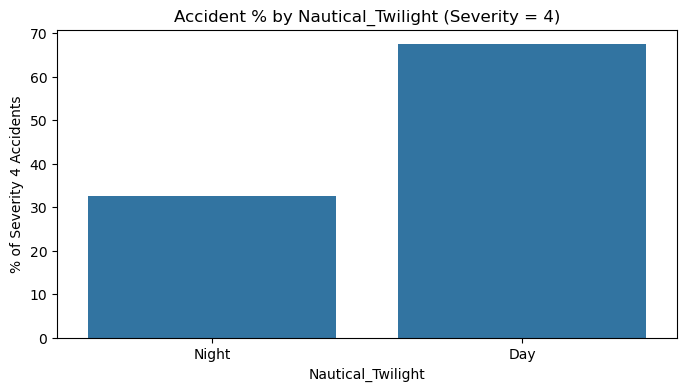

==================== Accident % by Astronomical_Twilight (Severity = 4) ====================


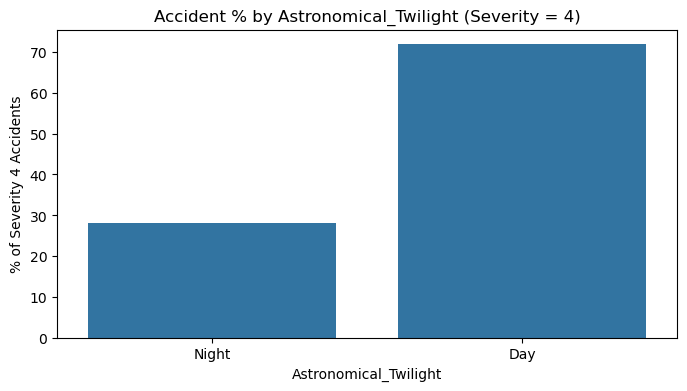

In [38]:
twilight_columns = ["Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]

for severity in sorted(unique_severity):
    filtered_df = df.filter(F.col("Severity") == severity)
    total = filtered_df.count()
    border(f"Severity {severity}")

    for feature in twilight_columns:
        grouped = filtered_df.groupBy(feature).count() \
            .withColumn("pct", F.col("count") / total * 100) \
            .toPandas()

        border(f"Accident % by {feature} (Severity = {severity})")
        plt.figure(figsize=(8, 4))
        sns.barplot(data=grouped, x=feature, y="pct")
        plt.xlabel(feature)
        plt.ylabel(f"% of Severity {severity} Accidents")
        plt.title(f"Accident % by {feature} (Severity = {severity})")
        plt.show()

## Dropping Unnecessary Features

In [39]:
cols_to_drop = ["Amenity", "Bump", "Give_Way", "No_Exit", "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming"]
df = df.drop(*cols_to_drop)

In [40]:
cols_to_drop = ["Duration_Minutes", "Duration_Hours"]
df = df.drop(*cols_to_drop)

## Binarise Severity (Target Variable)

In [41]:
df = df.withColumn("high_severity", (F.col("Severity") >= 3).cast("int"))

## Check for Duplicates

In [42]:
row_count = df.count()
df = df.dropDuplicates()
dupe_count = row_count - df.count()
print(f"Number of duplicate rows: {dupe_count}")

Number of duplicate rows: 0


## Check for Target Variable Imbalance (After cleaning)

==================== Checking for imbalance ====================

==================== Table ====================
+--------+-------+----------+
|Severity|  Count|Percentage|
+--------+-------+----------+
|       1|  61934|   1.17507|
|       2|4469929|  84.80756|
|       3| 613922|  11.64789|
|       4| 124888|   2.36949|
+--------+-------+----------+

==================== Barplot ====================


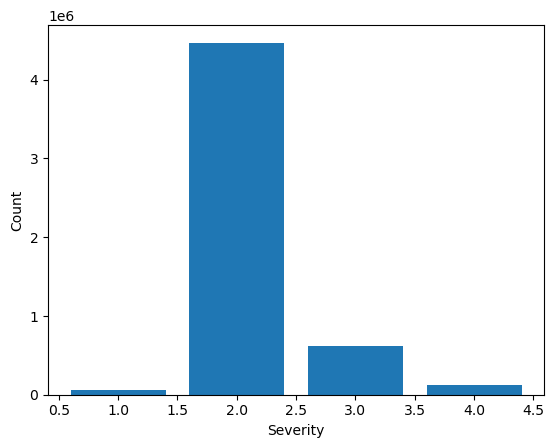

In [43]:
check_imbalance(df)

## Check for missing values (End of cleaning)

In [44]:
check_missing("df", df)

==================== Missing values in df ====================
+------------+----------------+--------+----------+--------+---------+---------+------------+------+----+------+-----+-------+--------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+--------+--------+--------------+--------------+--------------+-----------------+---------------------+---------------+----------------------+---------------+---------------------+-------------+--------------+--------------------+-------------+-------------------+----------------+-------------+
|Airport_Code|Start_Time_Month|Severity|Start_Time|End_Time|Start_Lat|Start_Lng|Distance(mi)|Street|City|County|State|Zipcode|Timezone|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Crossing|Junction|Traffic_Signal|Sunrise_Sunset|Civil_Twilight|Nautical_Twilight|Astronomical_Twilight|Start_Time_Year|Start_Ti

## Download Cleaned Data as Parquet

In [45]:
# Read directories
PROJECT_ROOT = Path.cwd().parent
OUTPUT_PARQUET_PATH = PROJECT_ROOT / "dataset/cleaned_parquet"

print("Project root:", PROJECT_ROOT)
print("Output parquet:", OUTPUT_PARQUET_PATH)

# Save parquet
df.write.mode("overwrite").parquet(str(OUTPUT_PARQUET_PATH))

Project root: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project
Output parquet: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\cleaned_parquet


In [46]:
spark.stop()

## Read cleaned_parquet file

In [47]:
# Create SparkSession
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("BT4221_Group4") \
    .config("spark.driver.memory", driver_memory) \
    .config("spark.sql.shuffle.partitions", cores * 3) \
    .config("spark.default.parallelism", cores) \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Verify SparkSession created successfully
print("App:", spark.sparkContext.appName)

# Read directories
PROJECT_ROOT = Path.cwd().parent
CLEANED_PARQUET_PATH = PROJECT_ROOT / "dataset/cleaned_parquet"

if not CLEANED_PARQUET_PATH.exists():
    raise FileNotFoundError(f"Original CSV not found at: {CLEANED_PARQUET_PATH}")

print("Project root:", PROJECT_ROOT)
print("Original Parquet:", CLEANED_PARQUET_PATH)

# Read parquet files
df = spark.read.parquet(str(CLEANED_PARQUET_PATH))

Existing Spark session stopped.
App: BT4221_Group4
Project root: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project
Original Parquet: c:\Users\iiank\OneDrive\Documents\NUS\Y2\Y2S2\BT4221\BT4221 Final Project\dataset\cleaned_parquet


## Categorise Columns

In [48]:
# Categorise column types
numerical_col = [f.name for f in df.schema.fields if isinstance(f.dataType, (IntegerType, DoubleType))]
bool_col = [f.name for f in df.schema.fields if isinstance(f.dataType, BooleanType)]
categorical_col = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType) and f.name != "ID"]

print(f"Numerical columns: {numerical_col}")
print(f"Boolean columns: {bool_col}")
print(f"Categorical columns: {categorical_col}")

Numerical columns: ['Start_Time_Month', 'Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Start_Time_Year', 'Start_Time_Day_of_Week', 'Start_Time_Hour', 'Start_Time_is_Weekend', 'End_Time_Year', 'End_Time_Month', 'End_Time_Day_of_Week', 'End_Time_Hour', 'End_Time_is_Weekend', 'high_severity']
Boolean columns: ['Crossing', 'Junction', 'Traffic_Signal']
Categorical columns: ['Airport_Code', 'Street', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


## Analysis for severity correlation

### Compare numerical feature means across binarised severity

high_severity      Low severity  High severity
Start_Lat               35.9663        36.9599
Start_Lng              -94.8327       -91.6757
Distance(mi)             0.6452         0.6361
Temperature(F)          61.2639        60.9425
Humidity(%)             64.5260        65.3000
Pressure(in)            29.3860        29.3235
Visibility(mi)           9.0644         9.0412
Wind_Speed(mph)          7.3140         7.7726
Precipitation(in)        0.0054         0.0081

==================== Start_Time_Month distribution - low vs high severity ====================


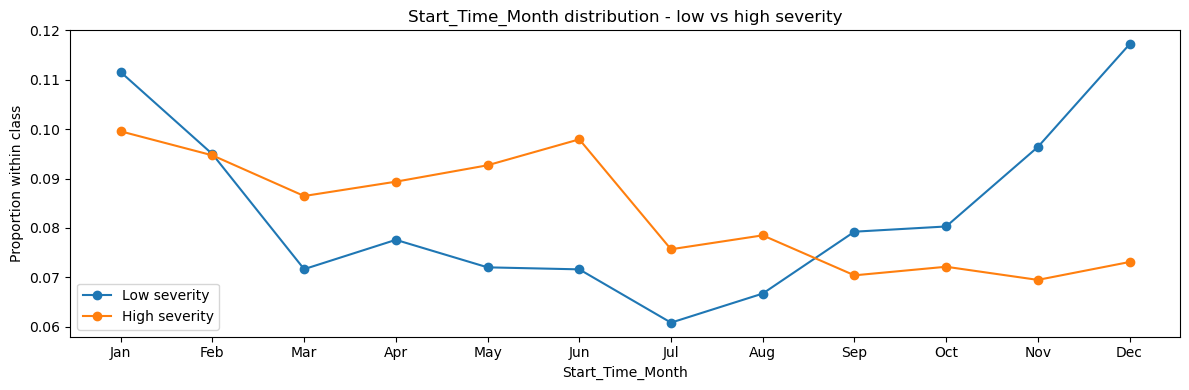


==================== Start_Time_Day_of_Week distribution - low vs high severity ====================


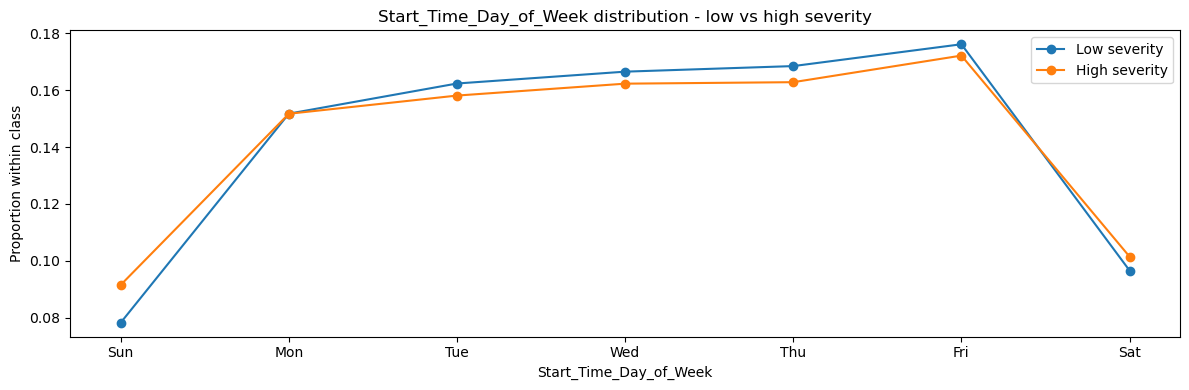


==================== Start_Time_Hour distribution - low vs high severity ====================


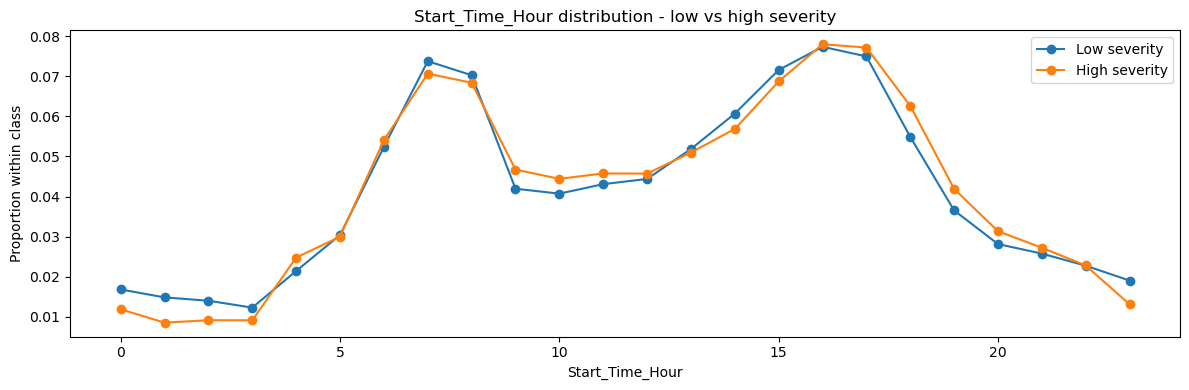


==================== Start_Time_is_Weekend distribution - low vs high severity ====================


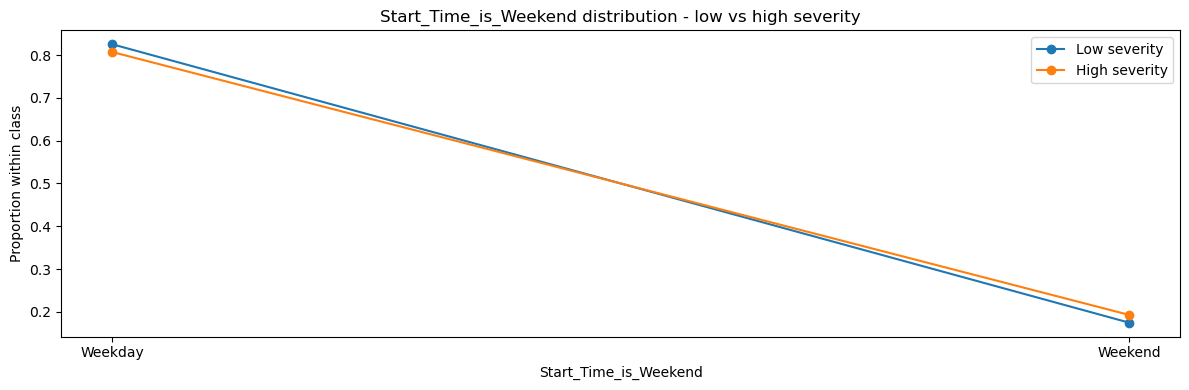

In [49]:
weather_spatial = [
    c for c in numerical_col 
    if c in ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)", "Distance(mi)", "Start_Lat", "Start_Lng"]
]

time_based = [
    c for c in numerical_col 
    if c in ["Start_Time_Month", "Start_Time_Day_of_Week", "Start_Time_Hour", "Start_Time_is_Weekend"]
]

skip = ["Severity", "high_severity", "Start_Time_Year", "End_Time_Year", "End_Time_Month", "End_Time_Day_of_Week", "End_Time_Hour", "End_Time_is_Weekend"]


# Table for weather/spatial
numerical_df = df.groupBy("high_severity").agg(
    *[F.round(F.mean(c), 4).alias(c) for c in weather_spatial]
).orderBy("high_severity")

numerical_pd = numerical_df.toPandas()
numerical_pd["high_severity"] = numerical_pd["high_severity"].map({0: "Low severity", 1: "High severity"})
numerical_pd = numerical_pd.set_index("high_severity").T
print(numerical_pd.to_string())

# Line graphs for time-based features
for c in time_based:
    time_df = df.groupBy("high_severity", c).count()
    time_df = time_df.withColumn("pct", F.col("count") / F.sum("count").over(Window.partitionBy("high_severity")))
    time_pd = time_df.toPandas()

    print()
    border(f"{c} distribution - low vs high severity")
    plt.figure(figsize=(12, 4))
    for sev, label in [(0, "Low severity"), (1, "High severity")]:
        sub = time_pd[time_pd["high_severity"] == sev].sort_values(c)
        plt.plot(sub[c], sub["pct"], marker="o", label=label)
    
    plt.xlabel(c)
    plt.ylabel("Proportion within class")
    plt.title(f"{c} distribution - low vs high severity")
    plt.legend()

    if c == "Start_Time_Month":
        plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    elif c == "Start_Time_Day_of_Week":
        plt.xticks(range(1, 8), ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"])
    elif c == "Start_Time_is_Weekend":
        plt.xticks([0, 1], ["Weekday", "Weekend"])

    plt.tight_layout()
    plt.show()

* Temperature(F), Humidity(%), Pressure(in), Visibility(mi), and Distance(mi) are nearly identical across low and high severity (differences being in the second or third decimal place)
* Wind_Speed(mph) shows the most noticeable difference (7.314 vs 7.7726). This indicates that high severity accidents tend to occur in sightly windier conditions
* Precipitation(in) is slightly higher for high severity (0.0054 vs 0.0081), but both values are extremely close to 0, indicating most accidents happen in dry conditions regardless of severity

### Compare boolean features across binarised severity

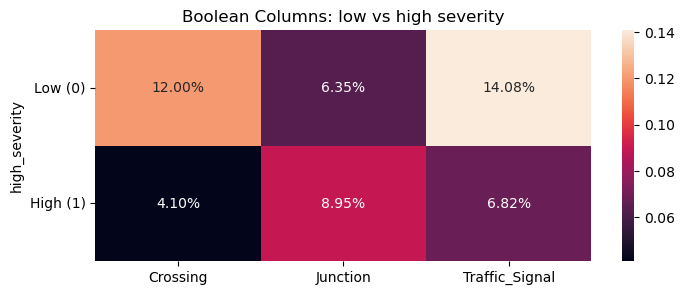

In [50]:
rate = df.groupBy("high_severity").agg(
    *[F.round(F.mean(F.col(p).cast("int")), 4).alias(p) for p in bool_col]
).orderBy("high_severity").toPandas().set_index("high_severity")

plt.figure(figsize=(8, 3))
sns.heatmap(rate, annot=True, fmt=".2%")
plt.title("Boolean Columns: low vs high severity")
plt.yticks([0.5, 1.5], ["Low (0)", "High (1)"], rotation=0)
plt.show()

* Crossing: more common in low severity (12.00% vs 4.10%). It is possible that crossings may slow traffic enough to reduce disruption spread
* Junction: more common in high severity (8.95% vs 6.35%). It is possible that junctions create more complex traffic disruption when accidents occur there
* Traffic Signal: notably more common in low severity (14.08% vs 6.82%). It is possible that signalised intersections may contain disruption better

From this heatmap, it suggests that infrastructure type does influence severity, and Junction in particular appears associated with higher severity accidents

### Compare categorical features across binarised severity


==================== Airport_Code distribution — low vs high severity (Top 20) ====================


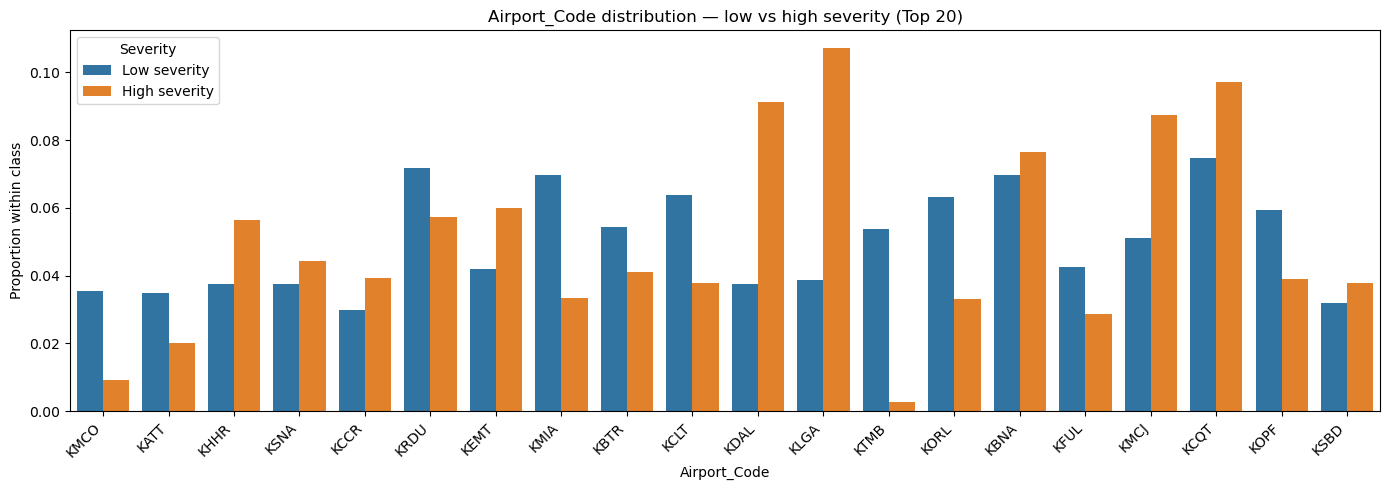


==================== Street distribution — low vs high severity (Top 20) ====================


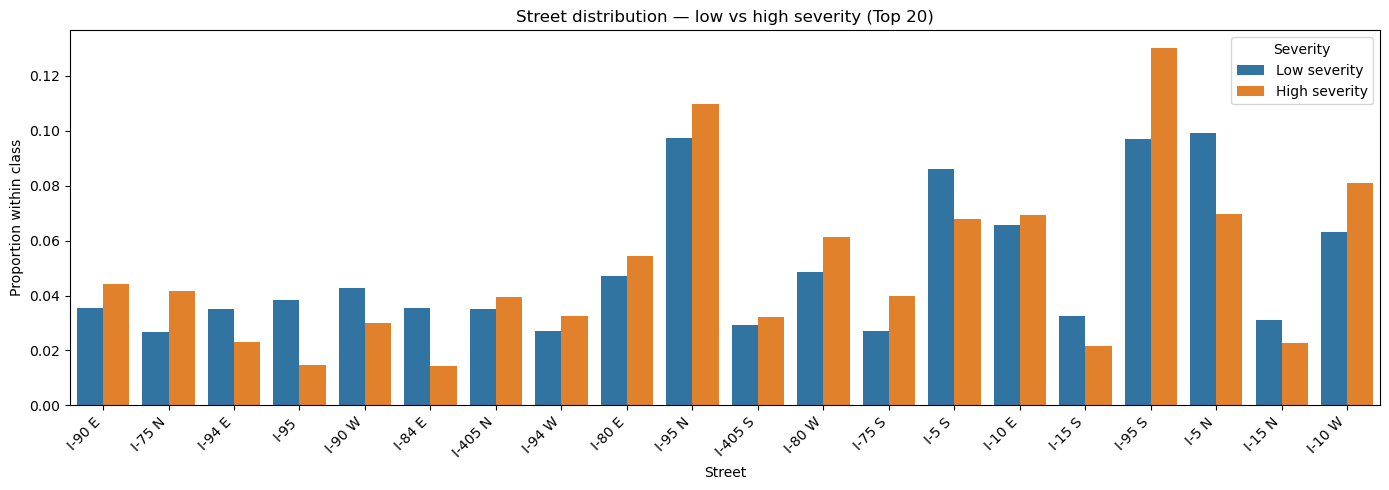


==================== City distribution — low vs high severity (Top 20) ====================


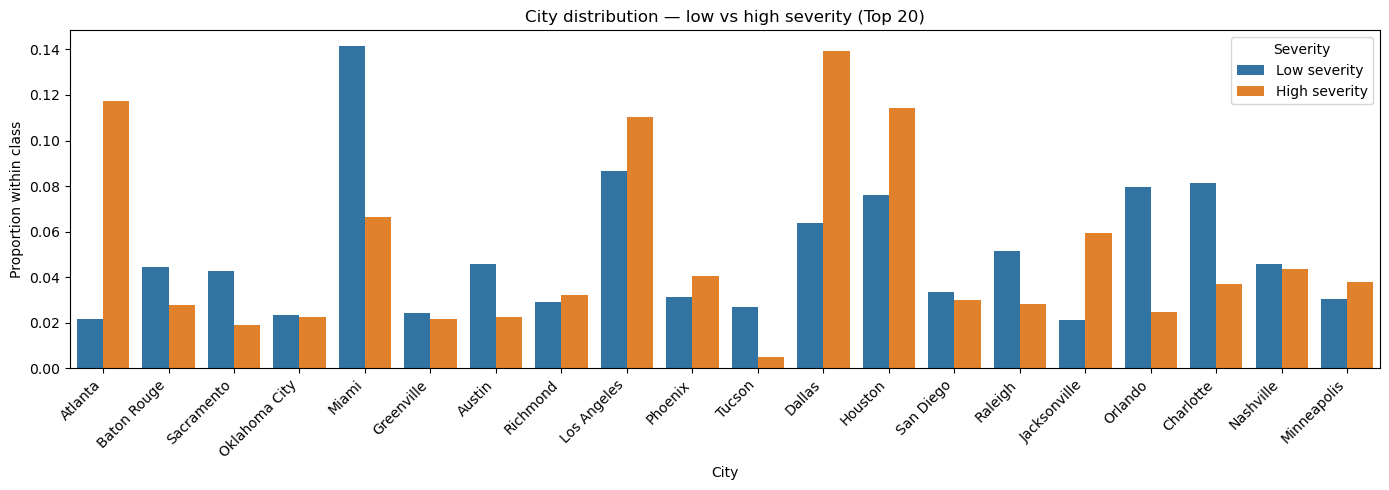


==================== County distribution — low vs high severity (Top 20) ====================


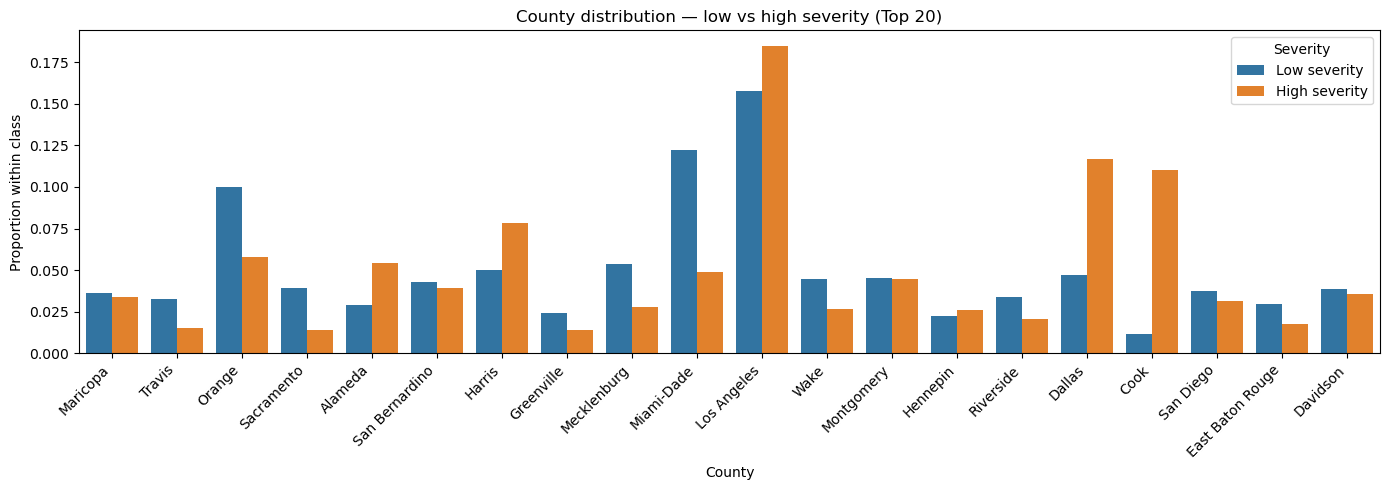


==================== State distribution — low vs high severity (Top 20) ====================


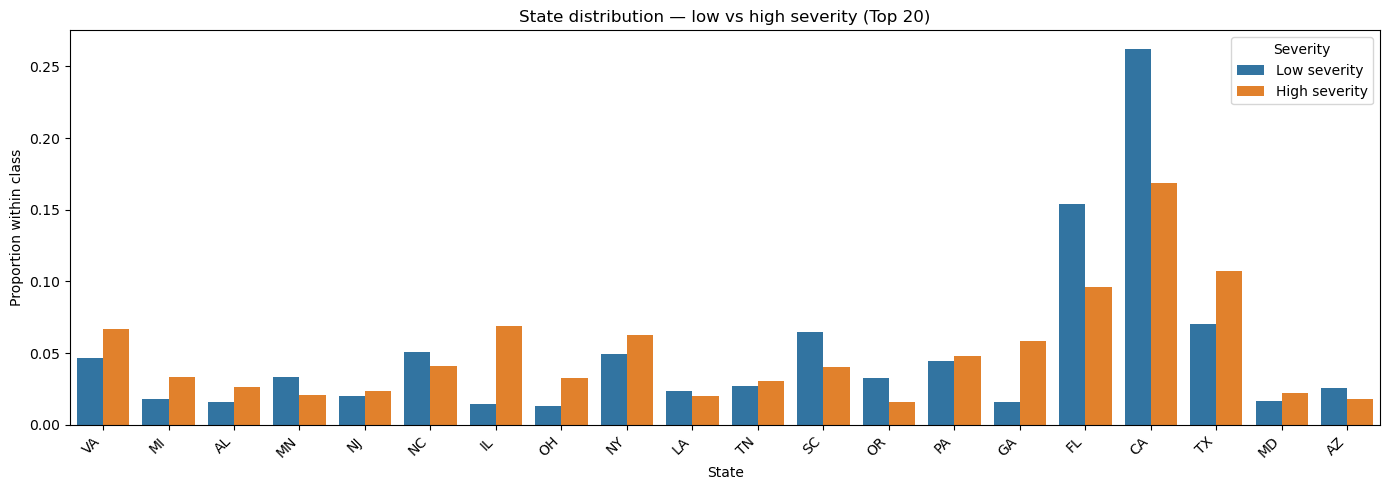


==================== Zipcode distribution — low vs high severity (Top 20) ====================


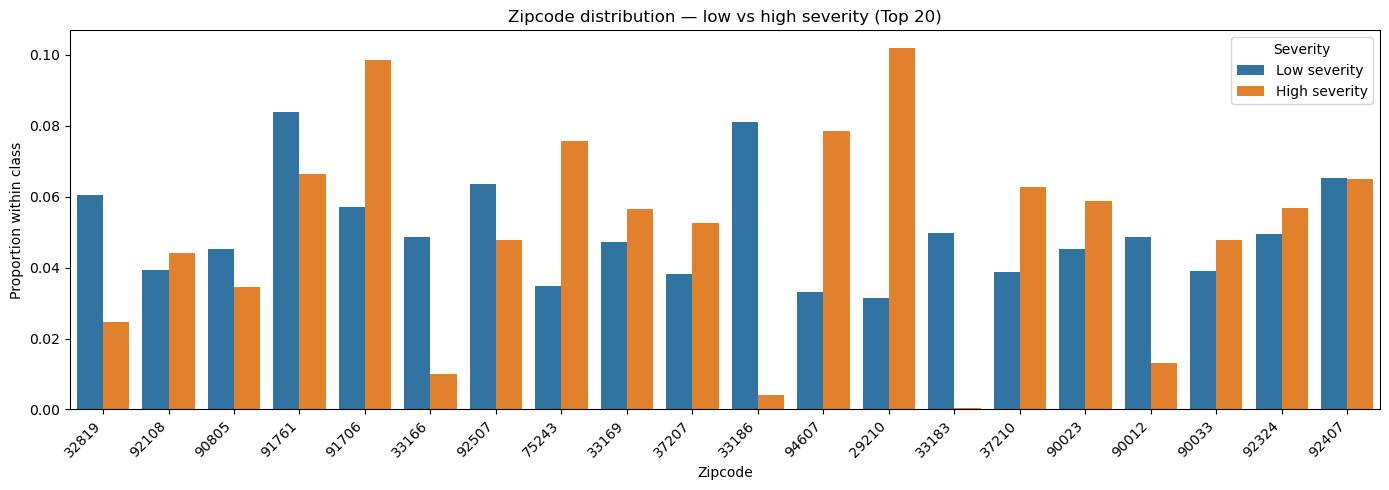


==================== Timezone distribution — low vs high severity  ====================


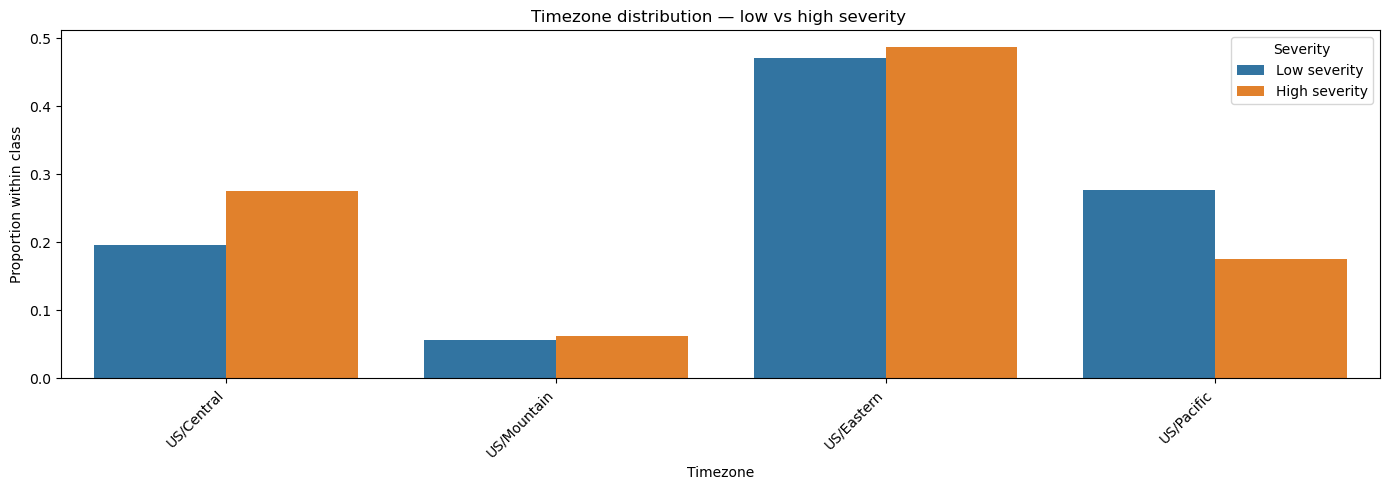


==================== Wind_Direction distribution — low vs high severity  ====================


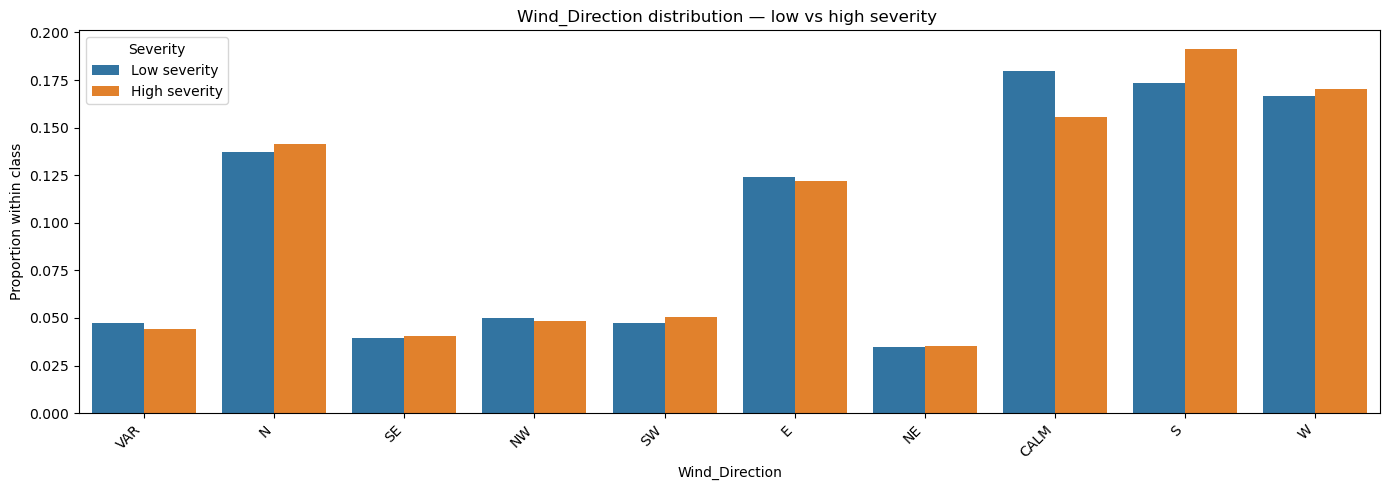


==================== Weather_Condition distribution — low vs high severity (Top 20) ====================


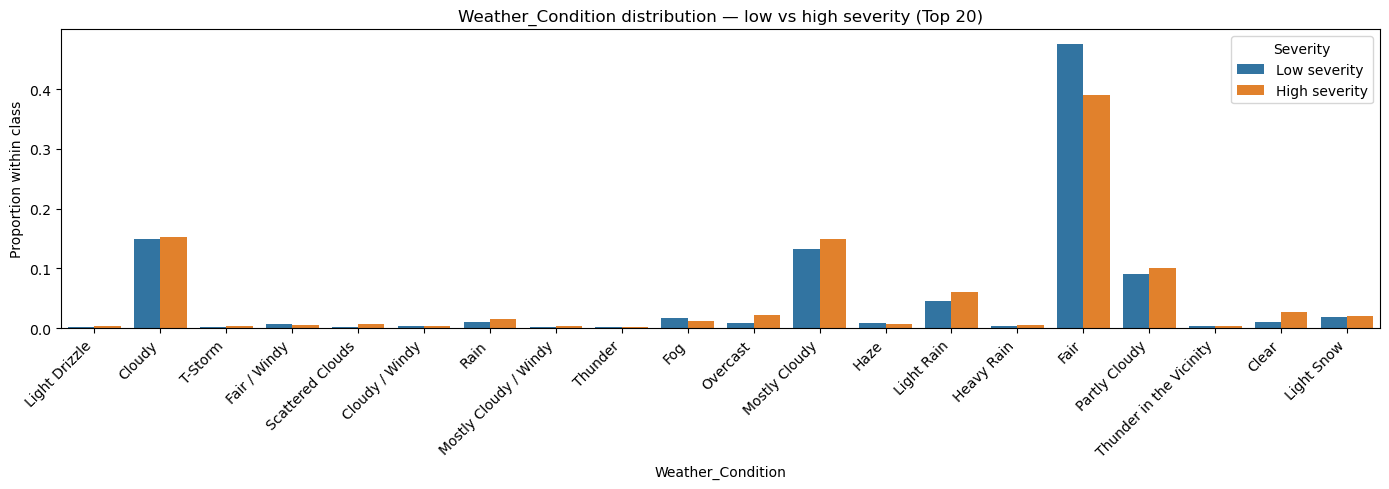


==================== Sunrise_Sunset distribution — low vs high severity  ====================


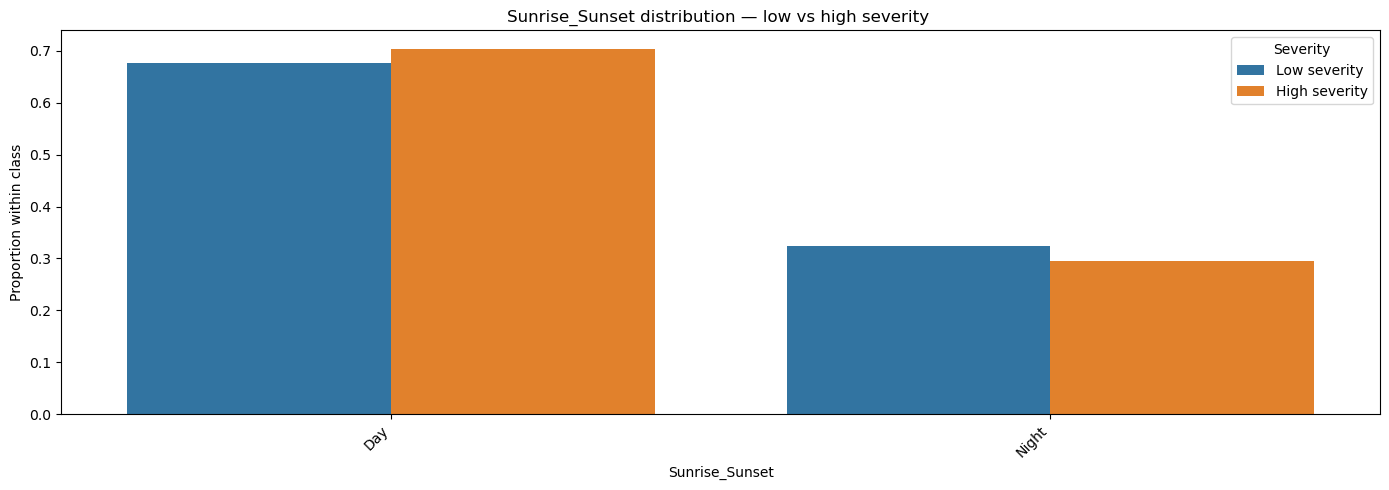


==================== Civil_Twilight distribution — low vs high severity  ====================


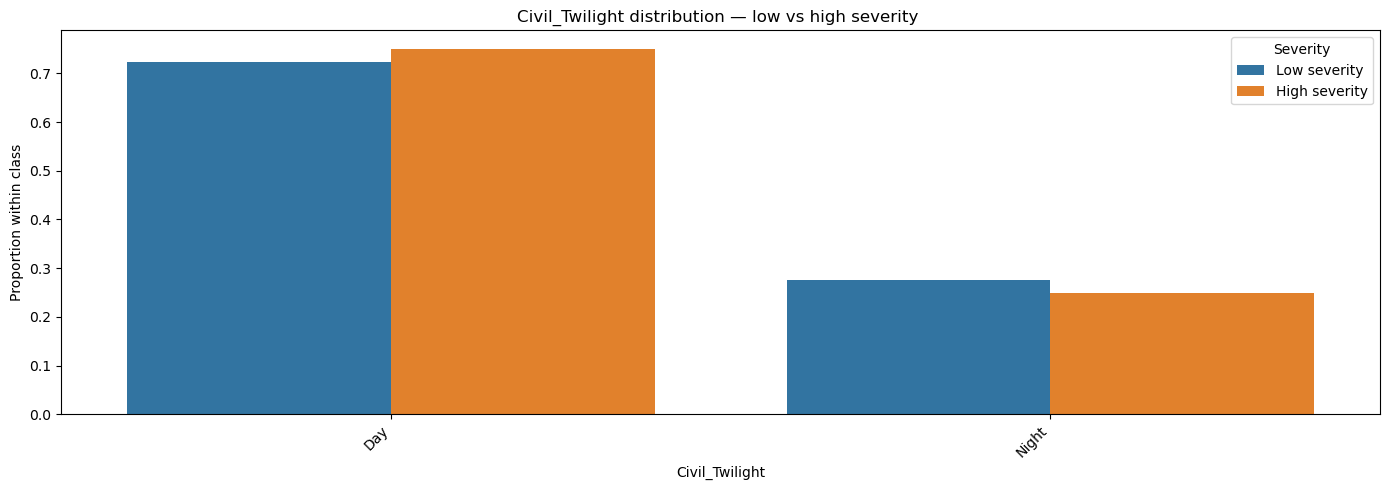


==================== Nautical_Twilight distribution — low vs high severity  ====================


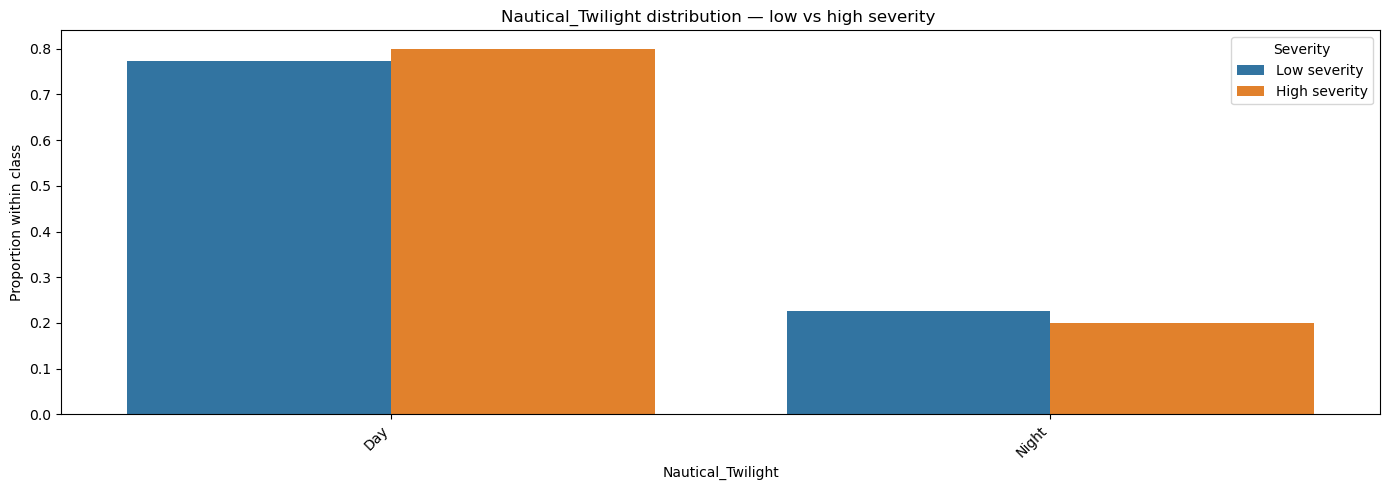


==================== Astronomical_Twilight distribution — low vs high severity  ====================


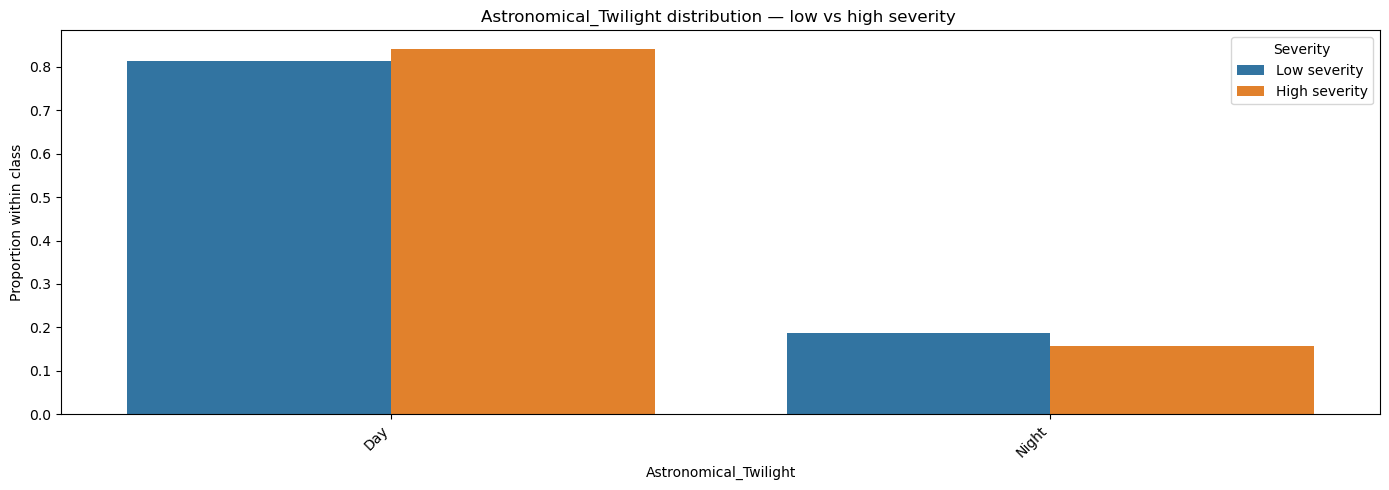

In [51]:
CARDINALITY_THRESHOLD = 20

for c in categorical_col:
    cardinality = df.select(c).distinct().count()
    
    if cardinality > CARDINALITY_THRESHOLD:
        top_vals = [row[c] for row in df.groupBy(c).count() \
            .orderBy(F.desc("count")) \
            .limit(20) \
            .collect()]
        plot_df = df.filter(F.col(c).isin(top_vals))
        title_suffix = "(Top 20)"
    else:
        plot_df = df
        title_suffix = ""

    cat_df = plot_df.groupBy("high_severity", c).count()
    cat_df = cat_df.withColumn("pct", F.col("count") / F.sum("count").over(Window.partitionBy("high_severity")))
    cat_pd = cat_df.toPandas()
    cat_pd["high_severity"] = cat_pd["high_severity"].map({0: "Low severity", 1: "High severity"})

    print()
    border(f"{c} distribution — low vs high severity {title_suffix}")
    plt.figure(figsize=(14, 5))
    sns.barplot(data=cat_pd, x=c, y="pct", hue="high_severity")
    plt.xlabel(c)
    plt.ylabel("Proportion within class")
    plt.title(f"{c} distribution — low vs high severity {title_suffix}")
    plt.legend(title="Severity")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### Correlation Matrix

==================== Pearson correlation matrix - all features ====================


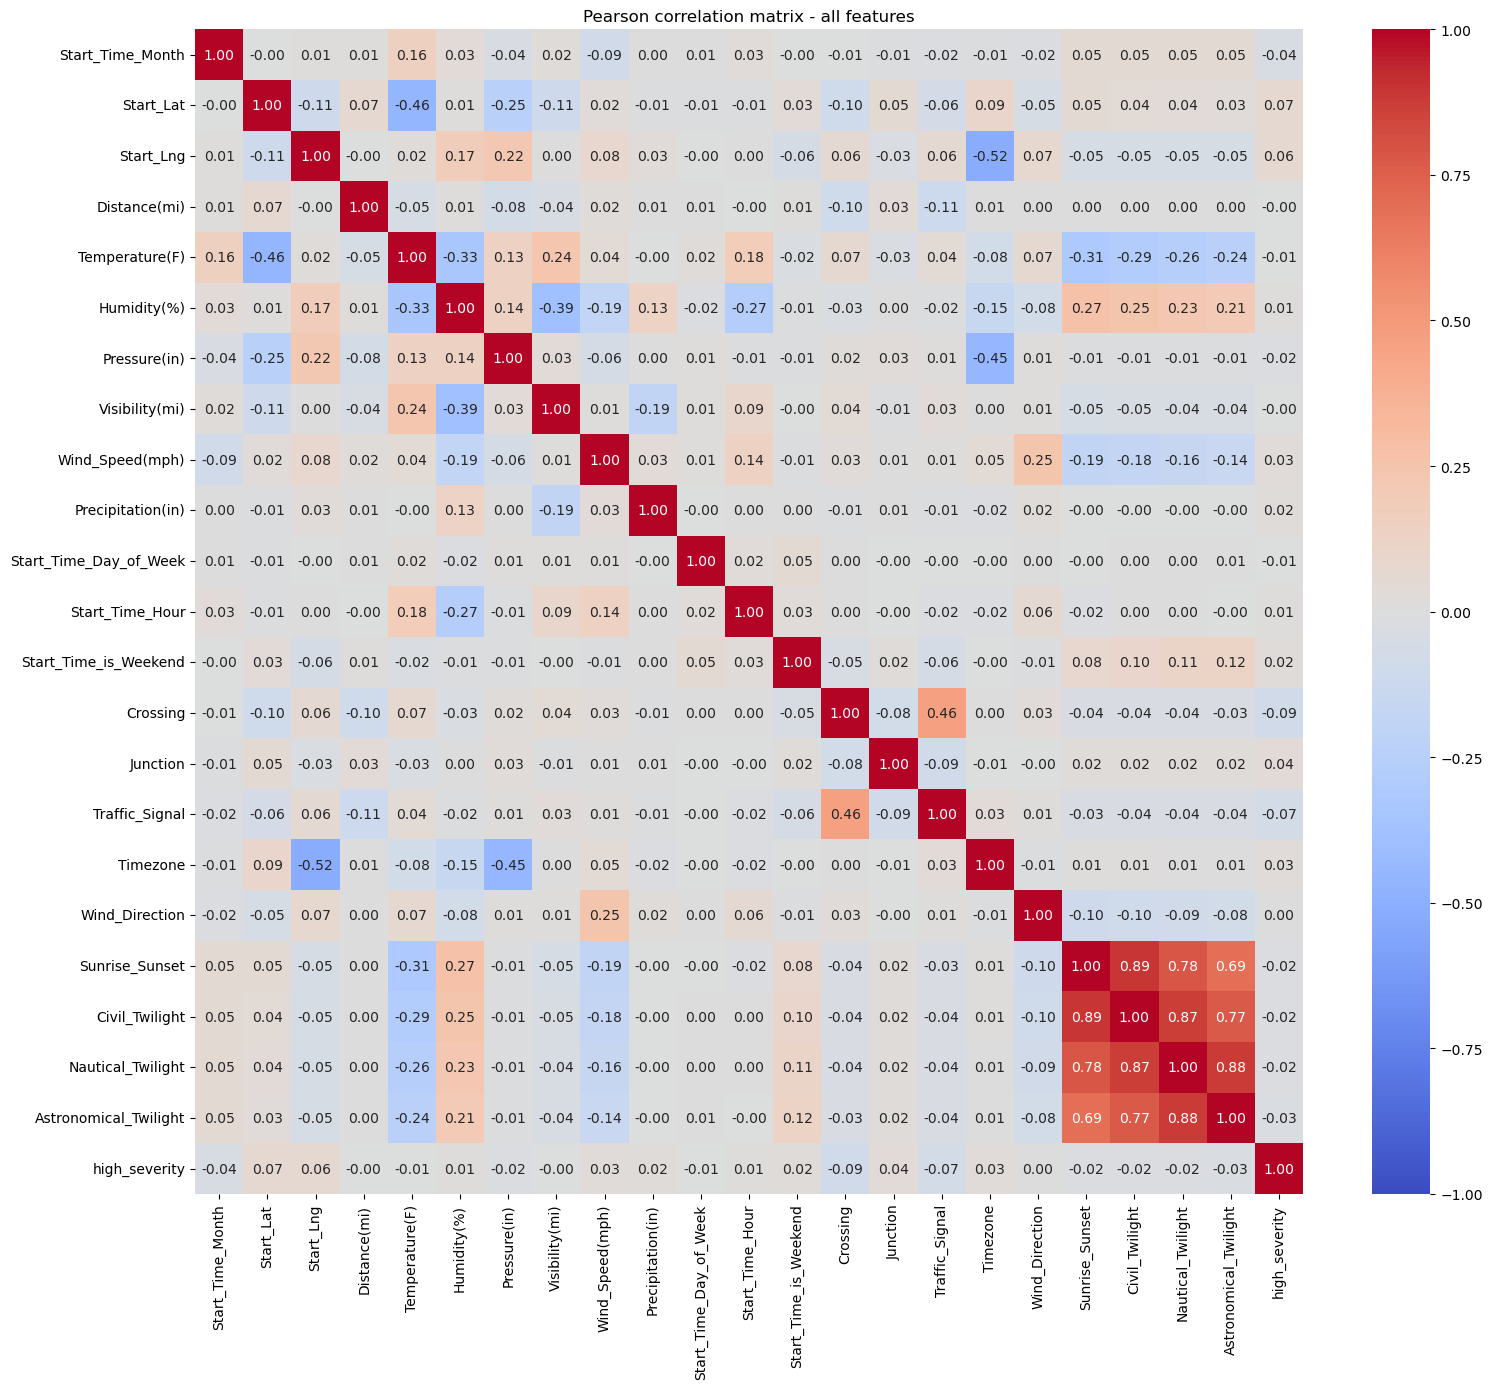

==================== Feature correlation with severity ====================


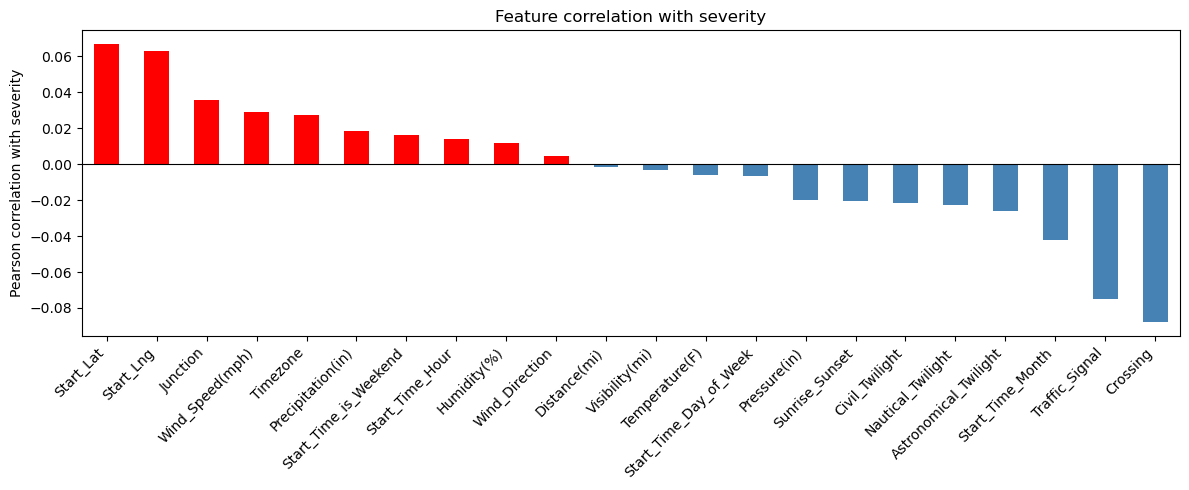

In [52]:
numerical = [c for c in numerical_col if c not in skip]

# Skip high cardinality categoricals
bool_cols = ["Crossing", "Junction", "Traffic_Signal"]
cat_cols = ["Timezone", "Wind_Direction", "Sunrise_Sunset", 
            "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]

for c in bool_cols:
    df = df.withColumn(c + "_int", F.col(c).cast("int"))

indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="skip") 
            for c in cat_cols]
pipeline = Pipeline(stages=indexers)
df_encoded = pipeline.fit(df).transform(df)

bool_int_cols = [c + "_int" for c in bool_cols]
cat_idx_cols = [c + "_idx" for c in cat_cols]
corr_features = numerical + bool_int_cols + cat_idx_cols + ["high_severity"]

assembler = VectorAssembler(inputCols=corr_features, outputCol="features", handleInvalid="skip")
vec_df = assembler.transform(df_encoded)
corr_matrix = Correlation.corr(vec_df, "features").head()[0].toArray()

clean_names = numerical + bool_cols + cat_cols + ["high_severity"]
corr_pd = pd.DataFrame(corr_matrix, index=clean_names, columns=clean_names)

border("Pearson correlation matrix - all features")
plt.figure(figsize=(16, 14))
sns.heatmap(corr_pd, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson correlation matrix - all features")
plt.tight_layout()
plt.show()

highsev_corr = corr_pd["high_severity"].drop("high_severity").sort_values(ascending=False)

border("Feature correlation with severity")
plt.figure(figsize=(12, 5))
highsev_corr.plot(kind="bar", 
                  color=["red" if v > 0 else "steelblue" for v in highsev_corr])
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Pearson correlation with severity")
plt.title("Feature correlation with severity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Visualisations for Average Duration (Seconds), Average Distance (Miles) and Accident Count against Severity (Note: I think this should go in the full EDA after processing)


In [53]:
summary_df = (
    df
    .groupBy("Severity")
    .agg(
        F.count("*").alias("Accident_Count"),
        F.round(F.avg("Duration_Seconds"), 2).alias("Avg_Duration_Seconds"),
        F.round(F.avg("Distance(mi)"), 2).alias("Avg_Distance")
    )
    .orderBy("Severity")
)

summary_df.show()

+--------+--------------+--------------------+------------+
|Severity|Accident_Count|Avg_Duration_Seconds|Avg_Distance|
+--------+--------------+--------------------+------------+
|       1|         61934|             2783.28|        0.11|
|       2|       4469929|             7625.05|        0.65|
|       3|        613922|             3885.45|        0.47|
|       4|        124888|             10991.5|        1.44|
+--------+--------------+--------------------+------------+



==================== Average Durations (Seconds) ====================


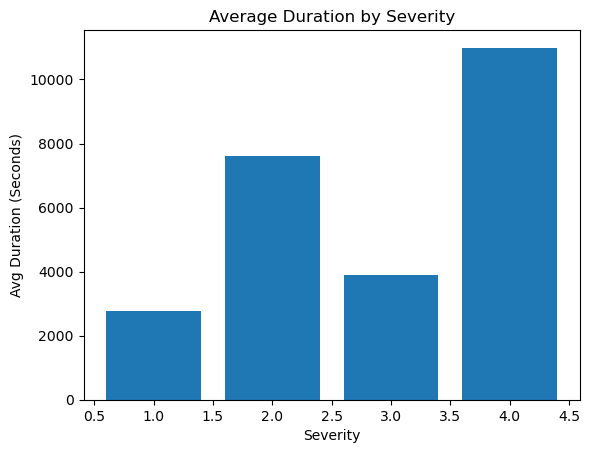


==================== Average Distance (Miles) ====================


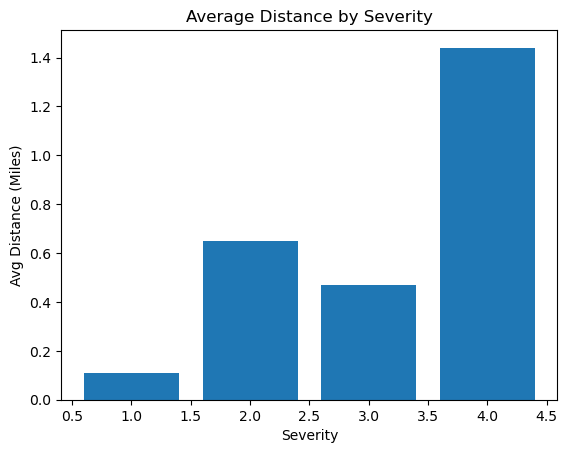


==================== Accident Count ====================


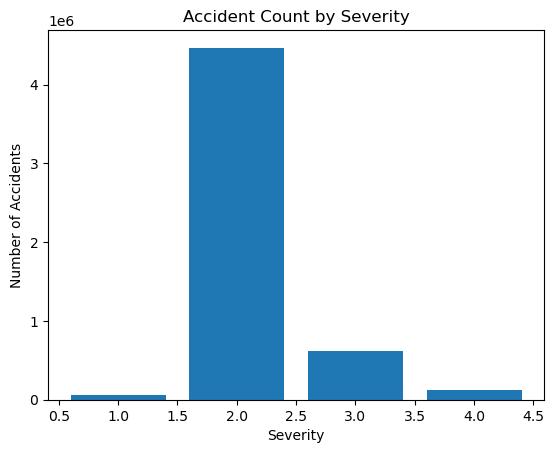

In [54]:
pd = summary_df.toPandas()

border("Average Durations (Seconds)")
plt.figure()
plt.bar(pd["Severity"], pd["Avg_Duration_Seconds"])
plt.xlabel("Severity")
plt.ylabel("Avg Duration (Seconds)")
plt.title("Average Duration by Severity")
plt.show()

print()
border("Average Distance (Miles)")
plt.figure()
plt.bar(pd["Severity"], pd["Avg_Distance"])
plt.xlabel("Severity")
plt.ylabel("Avg Distance (Miles)")
plt.title("Average Distance by Severity")
plt.show()

print()
border("Accident Count")
plt.figure()
plt.bar(pd["Severity"], pd["Accident_Count"])
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")
plt.title("Accident Count by Severity")
plt.show()

## Feature Engineering / Selection

### Encoding

In [55]:
# # StringIndexer on 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'
# # handleInvalid drops the NA rows already
# indexer = StringIndexer(
#     inputCols=['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'],
#     outputCols=['Sunrise_Sunset_index', 'Civil_Twilight_index', 'Nautical_Twilight_index', 'Astronomical_Twilight_index'],
#     handleInvalid='skip'
# )
# demo_df = indexer.fit(df).transform(df)

### Processing Weather_Condition into boolean cols



In [56]:
# weather_rows = df.select("Weather_Condition").distinct().collect()

In [57]:
# weather_list = [row.Weather_Condition for row in weather_rows if row.Weather_Condition is not None]
# for weather in weather_list:
#     print(weather)

In [58]:
# # Replace all "T-" with "thunder"
# df = df.withColumn(
#     "Weather_Condition",
#     F.regexp_replace(F.col("Weather_Condition"), "T-", "thunder ")
# )

# # Find top word
# common_words = (
#     df.select(
#         F.explode(
#             F.split(
#                 F.lower(F.col("Weather_Condition")), r"\W+"
#             )
#         ).alias("word")
#     )
#     .filter(F.col("word").isNotNull())
#     # this line can be generalised
#     .filter(~F.col("word").isin(["light", "heavy", "n", "a", "vicinity", ""]))
#     # for instance, get the LLM to create a list of non-weather words that are present
#     # and eliminate them here
#     .groupBy("word")
#     .agg(F.count("*").alias("count"))
#     .orderBy(F.desc("count"))
# )

# common_words.show(30)

In [59]:
# # dict of {feature_name : regex}
# weather_mappings = {
#     "clear": "fair|clear",
#     "cloudy": "cloud|overcast|scattered|mostly|partly",
#     "rain": "rain|storm|drizzle|shower|thunderstorm",
#     "snow": "snow|sleet|ice|pellets|squall",
#     "thunder": "thunder|t-storm|storm|thunderstorm",
#     "windy": "windy|squall",
#     "fog": "fog|haze|mist"
# }

In [60]:
# # create .lower() column
# df_features = df.withColumn("weather_temp", F.lower(F.col("Weather_Condition")))

# # create dictionary of mappings cause lazy + easier to automate in agent
# feature_expressions = {}
# for name, pattern in weather_mappings.items():
#   feature_expressions[f"is_{name}"] = F.col("weather_temp").rlike(pattern).cast("boolean")

# # apply withColumns
# df_features = df_features.withColumns(feature_expressions).drop("weather_temp")

# # Demonstration for us: check results for a mix of conditions
# df_features.select(
#     "Weather_Condition", "is_clear", "is_cloudy", "is_rain", "is_snow", "is_thunder", "is_windy", "is_fog"
# ).dropna(subset=["Weather_Condition"]).orderBy("is_clear").show(20, truncate=False)

## Stop Spark

In [61]:
spark.stop()